# Notebook 2: Computational Imaging | From Gradient Descent to Black Holes
---

On April 10, 2019, the Event Horizon Telescope revealed the first image of a black hole, the supermassive black hole M87\*.

![M87* Black Hole](./data/M87_black_hole.jpg)

**But this image is NOT a photograph.**

It was **reconstructed** using the same technique we just learned: *gradient descent on a loss function.*

No single telescope on Earth can resolve a black hole shadow. Instead, radio dishes across the globe were linked together to form an Earth-sized virtual telescope. The raw data? Sparse, noisy Fourier measurements, just a tiny fraction of what a complete image requires.

**The image you saw was computed, not captured. And in this notebook, you will do it yourself.**

---

# Why Imaging Is Hard ? |  Fourier Transforms & Interferometry

---

## What Your Camera Actually Does

Before we reconstruct a black hole image, we need to understand what a telescope (or any camera) actually measures.

Let's start with a simple model: a **ring**, a toy version of a black hole shadow.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=300
plt.rcParams["xtick.direction"]="out"
plt.rcParams["ytick.direction"]="out"
plt.rcParams['font.family'] = 'sans-serif'
import jax
import jax.numpy as jnp
%matplotlib inline

# Create a ring image — our simple "black hole shadow" model
N = 128
y, x = np.mgrid[-N//2:N//2, -N//2:N//2]
r = np.sqrt(x**2 + y**2).astype(float)
ring = np.exp(-((r - 30)**2) / (2 * 5.0**2))
ring = ring / ring.sum()

### The image in "pixel space"

This is how we normally think of images: a grid of pixel values. Bright pixels have large values, dark pixels are near zero.

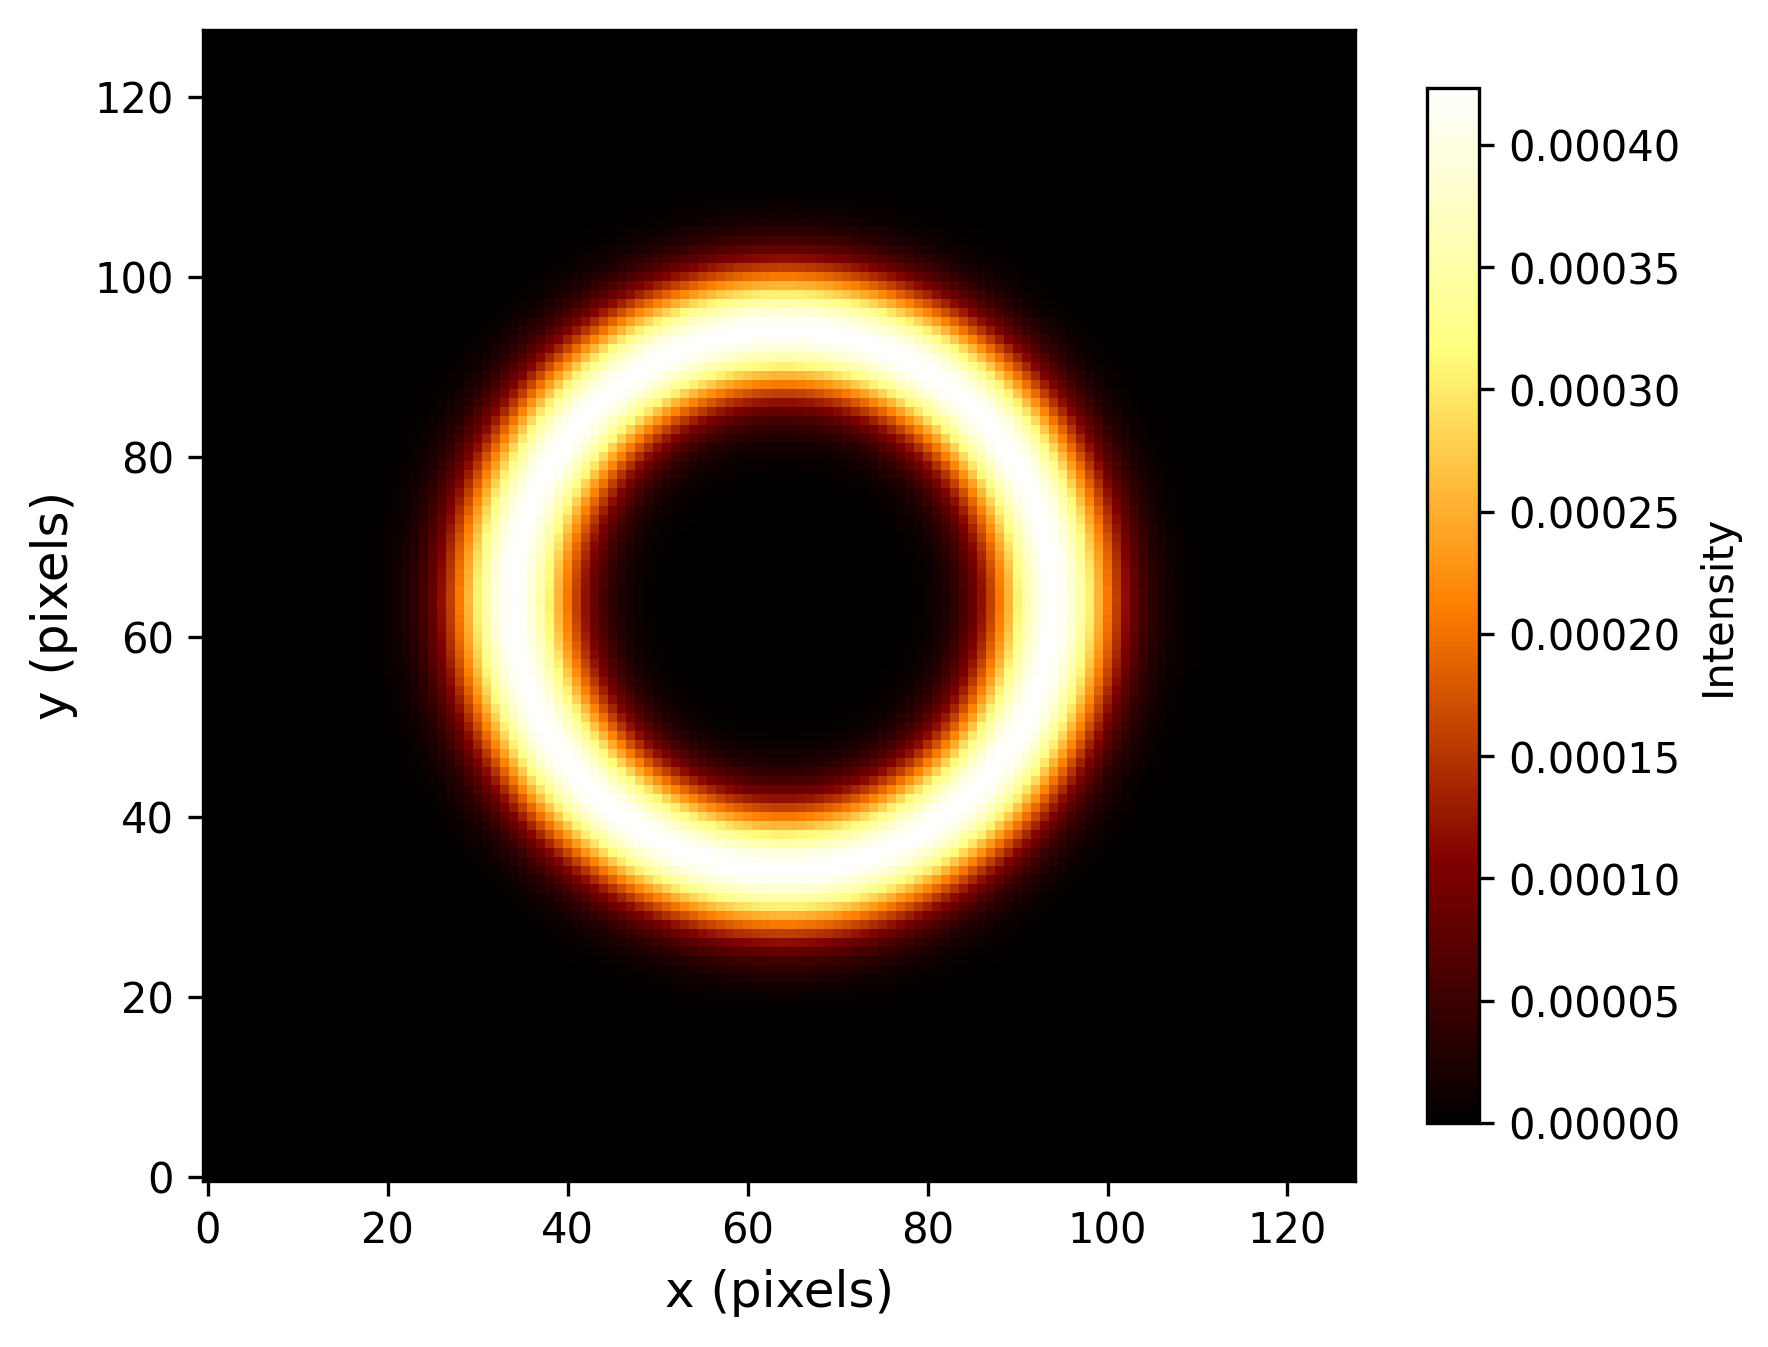

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.imshow(ring, cmap='afmhot', origin='lower')
ax.set_xlabel('x (pixels)', fontsize=12)
ax.set_ylabel('y (pixels)', fontsize=12)
plt.colorbar(im, ax=ax, label='Intensity', shrink=0.8)
plt.tight_layout()
plt.show()

### The image in "Fourier space"

Every image can be decomposed into a sum of sinusoidal waves at different **spatial frequencies**. This is the 2D Fourier Transform:

$$\hat{I}(u,v) = \iint I(x,y)\, e^{-2\pi i(ux+vy)}\, dx\, dy$$

- **Low frequencies** $(u,v) \approx 0$: Large-scale, smooth structure
- **High frequencies** $(u,v)$ far from origin: Fine details, sharp edges

The Fourier transform produces **complex numbers** at each frequency. We can visualize the **amplitude** (how much of each frequency) and **phase** (where the wave peaks are).

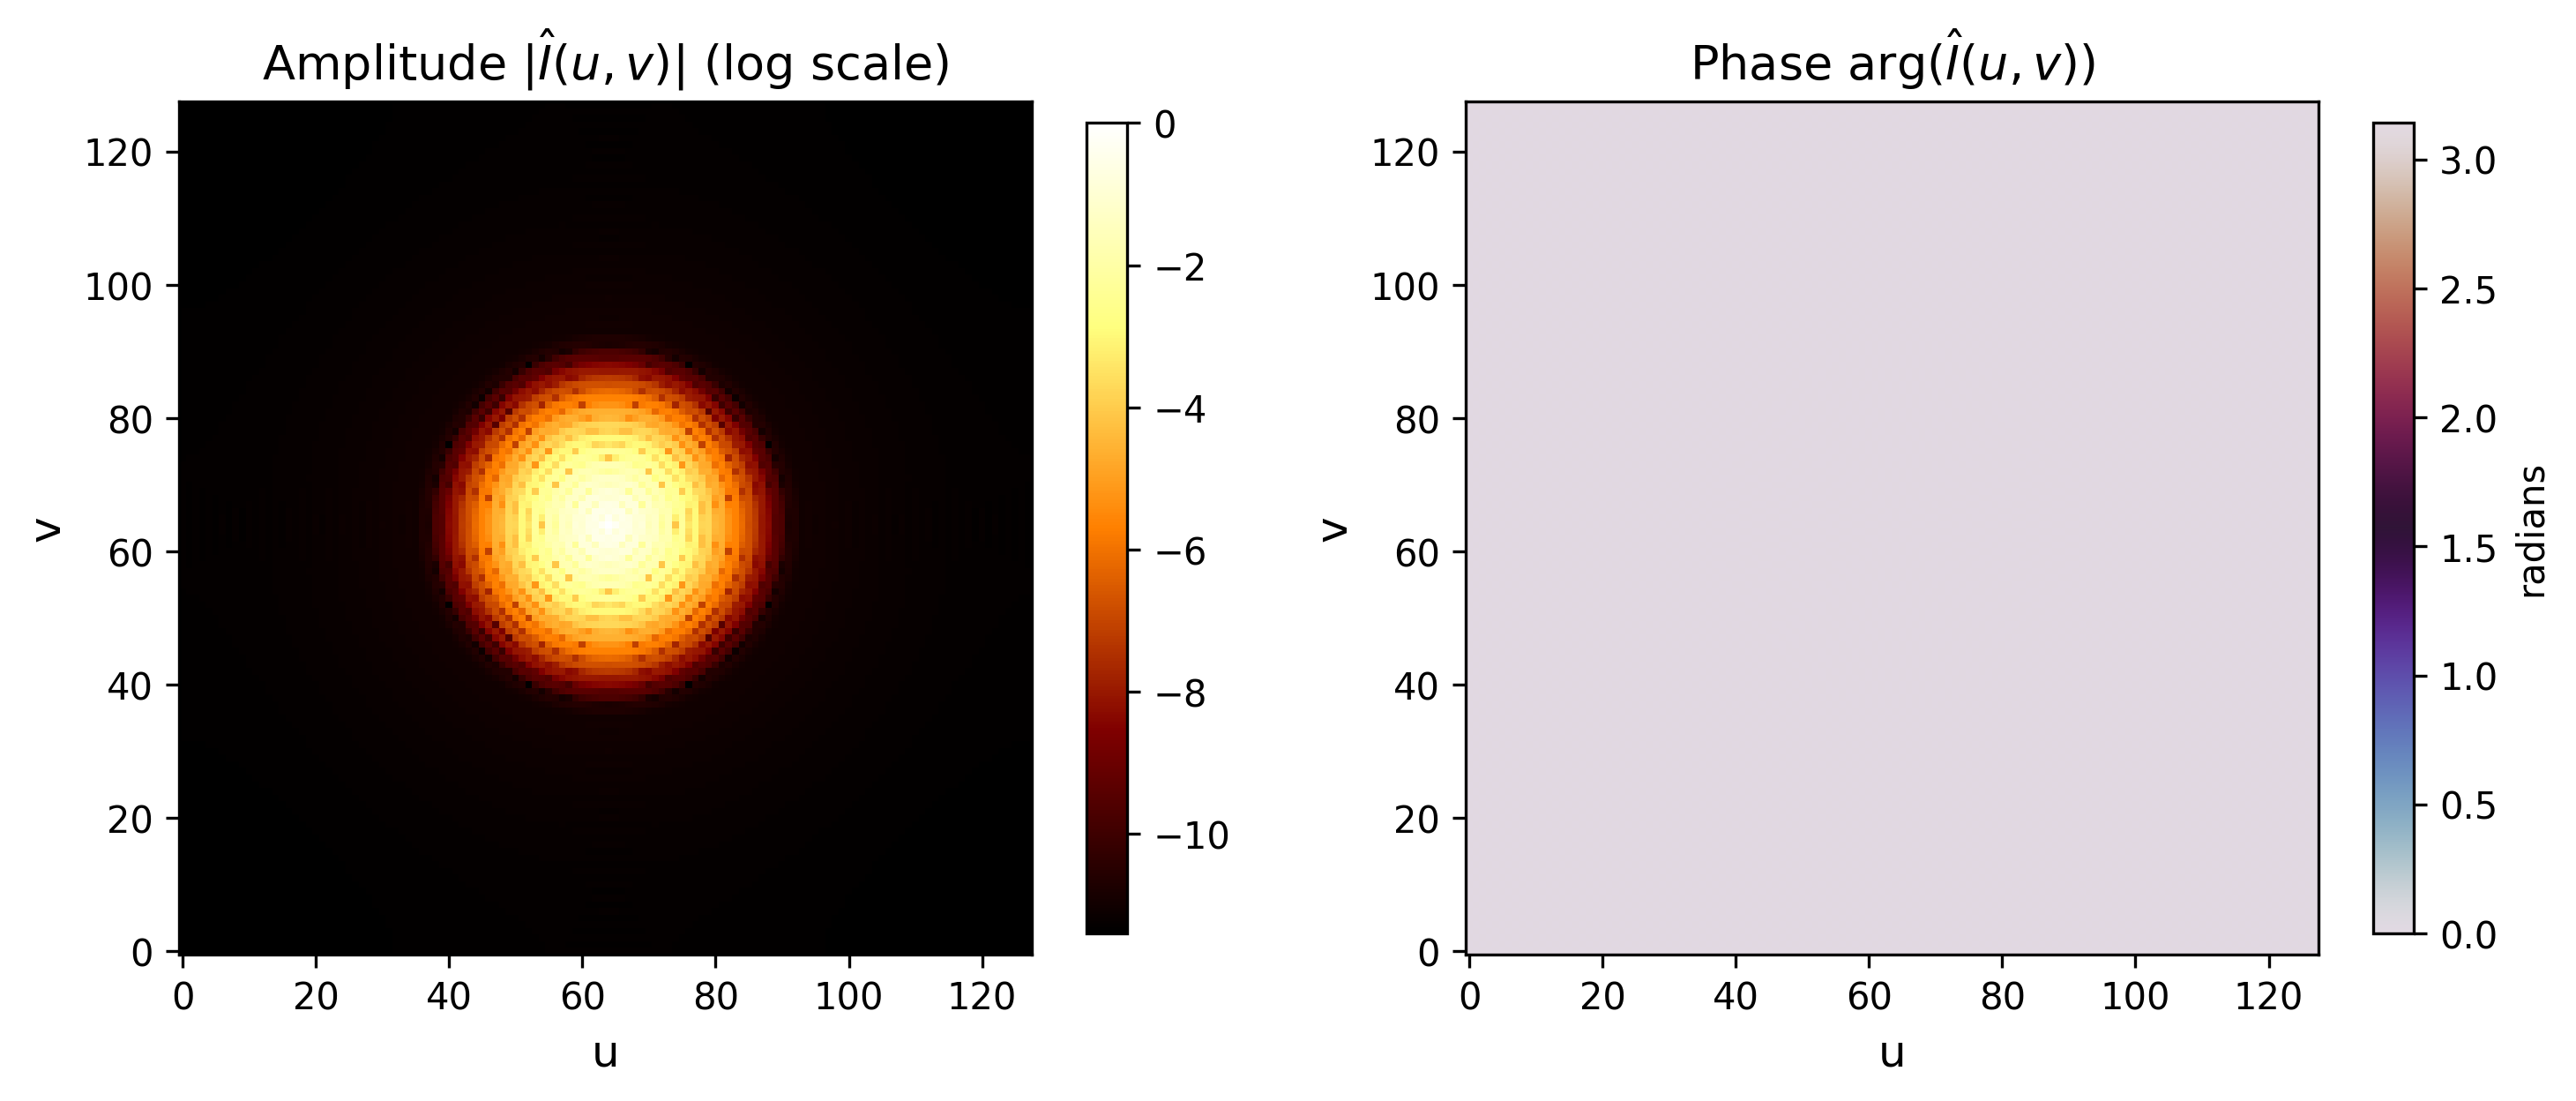

In [8]:
# Compute the 2D Fourier Transform
ring_fft = np.fft.fftshift(np.fft.fft2(ring))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Amplitude (log scale)
amp = np.abs(ring_fft)
im0 = axes[0].imshow(np.log10(amp + 1e-12), cmap='afmhot', origin='lower')
axes[0].set_title('Amplitude $|\hat{I}(u,v)|$ (log scale)', fontsize=13)
axes[0].set_xlabel('u', fontsize=12)
axes[0].set_ylabel('v', fontsize=12)
plt.colorbar(im0, ax=axes[0], shrink=0.95)

# Phase
im1 = axes[1].imshow(np.angle(ring_fft), cmap='twilight', origin='lower')
axes[1].set_title('Phase $\\arg(\hat{I}(u,v))$', fontsize=13)
axes[1].set_xlabel('u', fontsize=12)
axes[1].set_ylabel('v', fontsize=12)
plt.colorbar(im1, ax=axes[1], shrink=0.95, label='radians')

plt.tight_layout()
plt.show()

Notice the ring structure in the Fourier amplitude! A ring in image space creates a ring-like pattern in Fourier space. The Fourier transform of a Gaussian ring is related to Bessel functions.

### What do different frequencies encode?

Let's find out by selectively **keeping** and **removing** different parts of the Fourier plane.

#### Low frequencies only: large-scale structure

We mask out the high frequencies (far from center) and inverse-transform.

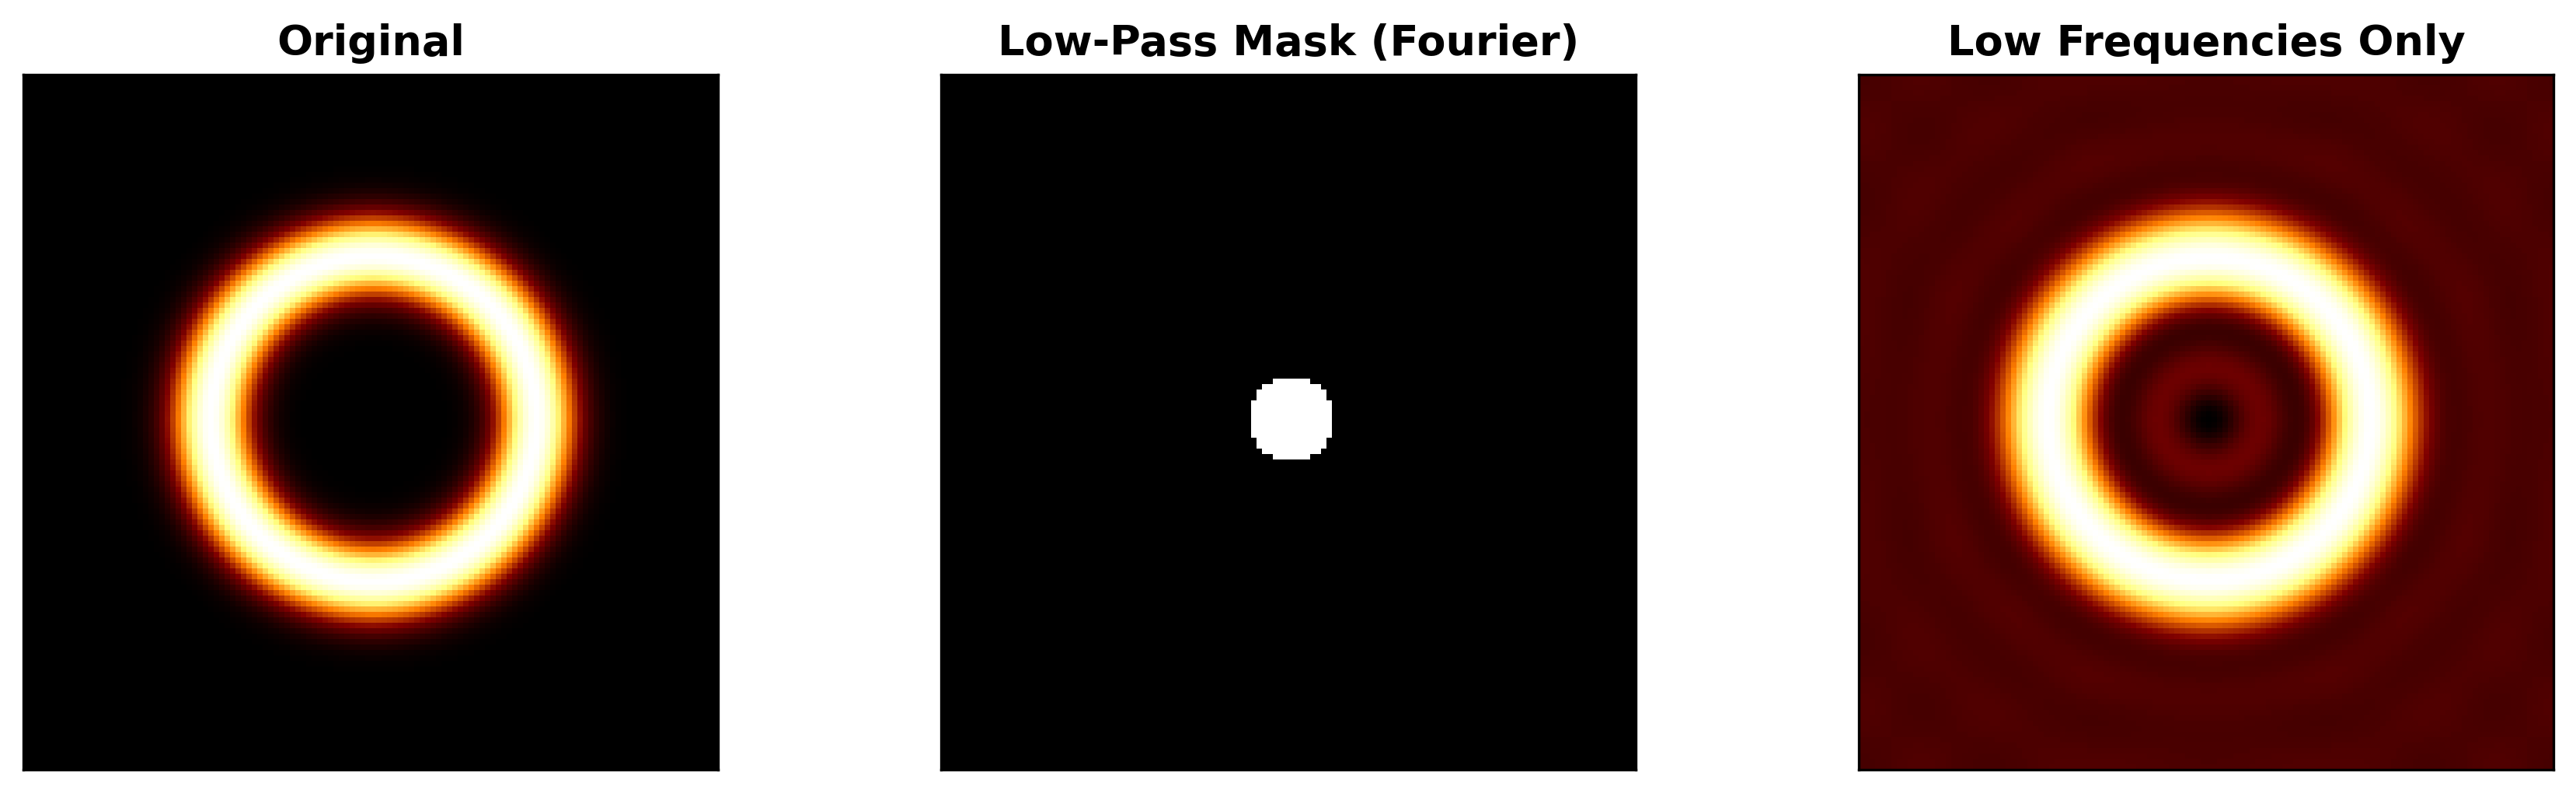

Low frequencies = large-scale structure. The ring's overall shape is there, but it's blurry.


In [15]:
# Mask out high frequencies — keep only low frequencies
uu, vv = np.mgrid[-N//2:N//2, -N//2:N//2]
freq_radius = np.sqrt(uu**2 + vv**2)

low_pass_mask = (freq_radius < 8).astype(float)
ring_lowpass = np.fft.ifft2(np.fft.ifftshift(ring_fft * low_pass_mask)).real

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].imshow(ring, cmap='afmhot', origin='lower')
axes[0].set_title('Original', fontsize=13, fontweight='bold')

axes[1].imshow(low_pass_mask, cmap='gray', origin='lower')
axes[1].set_title('Low-Pass Mask (Fourier)', fontsize=13, fontweight='bold')

axes[2].imshow(ring_lowpass, cmap='afmhot', origin='lower')
axes[2].set_title('Low Frequencies Only', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()
print("Low frequencies = large-scale structure. The ring's overall shape is there, but it's blurry.")

#### High frequencies only: fine details and edges

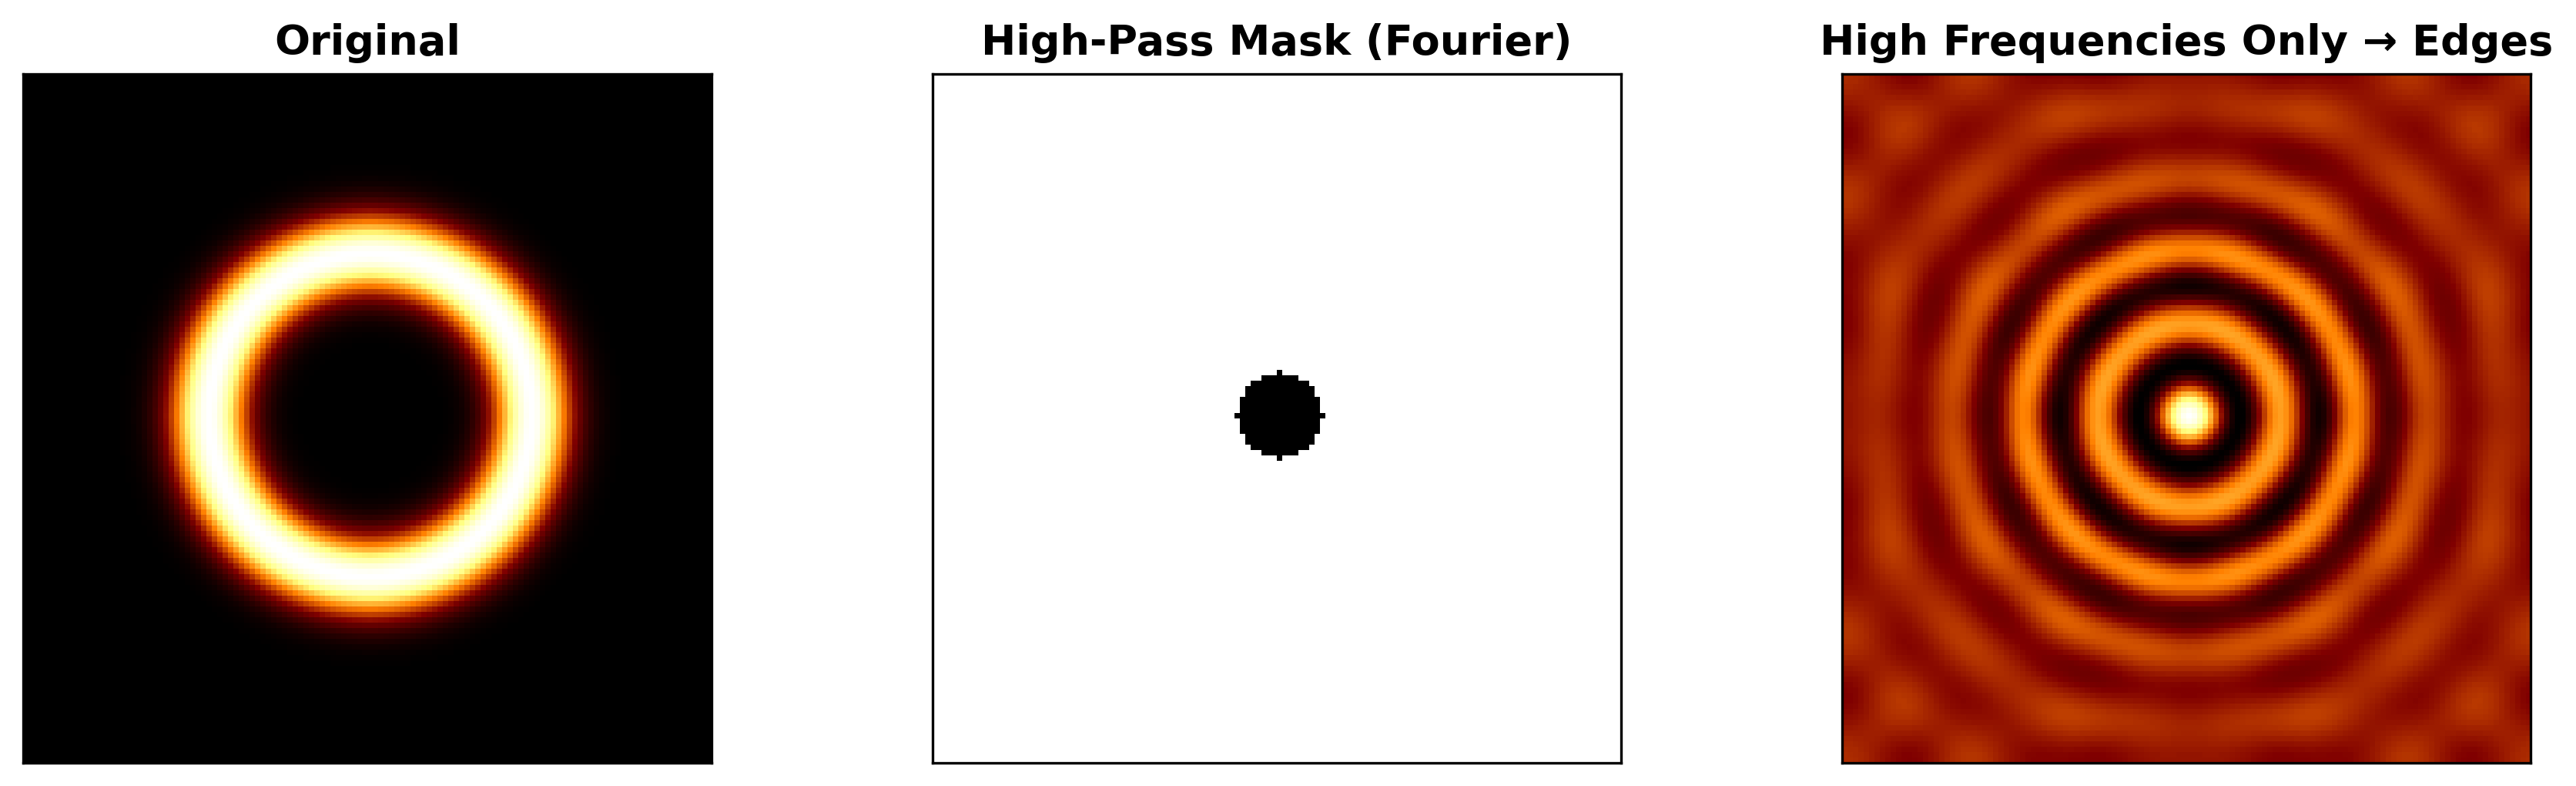

High frequencies = fine details. We see the sharp edges of the ring, but no overall brightness.


In [16]:
# Mask out low frequencies — keep only high frequencies
high_pass_mask = (freq_radius > 8).astype(float)
ring_highpass = np.fft.ifft2(np.fft.ifftshift(ring_fft * high_pass_mask)).real

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].imshow(ring, cmap='afmhot', origin='lower')
axes[0].set_title('Original', fontsize=13, fontweight='bold')

axes[1].imshow(high_pass_mask, cmap='gray', origin='lower')
axes[1].set_title('High-Pass Mask (Fourier)', fontsize=13, fontweight='bold')

axes[2].imshow(ring_highpass, cmap='afmhot', origin='lower')
axes[2].set_title('High Frequencies Only → Edges', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()
print("High frequencies = fine details. We see the sharp edges of the ring, but no overall brightness.")

### Progressive frequency removal

What happens as we keep fewer and fewer Fourier components?

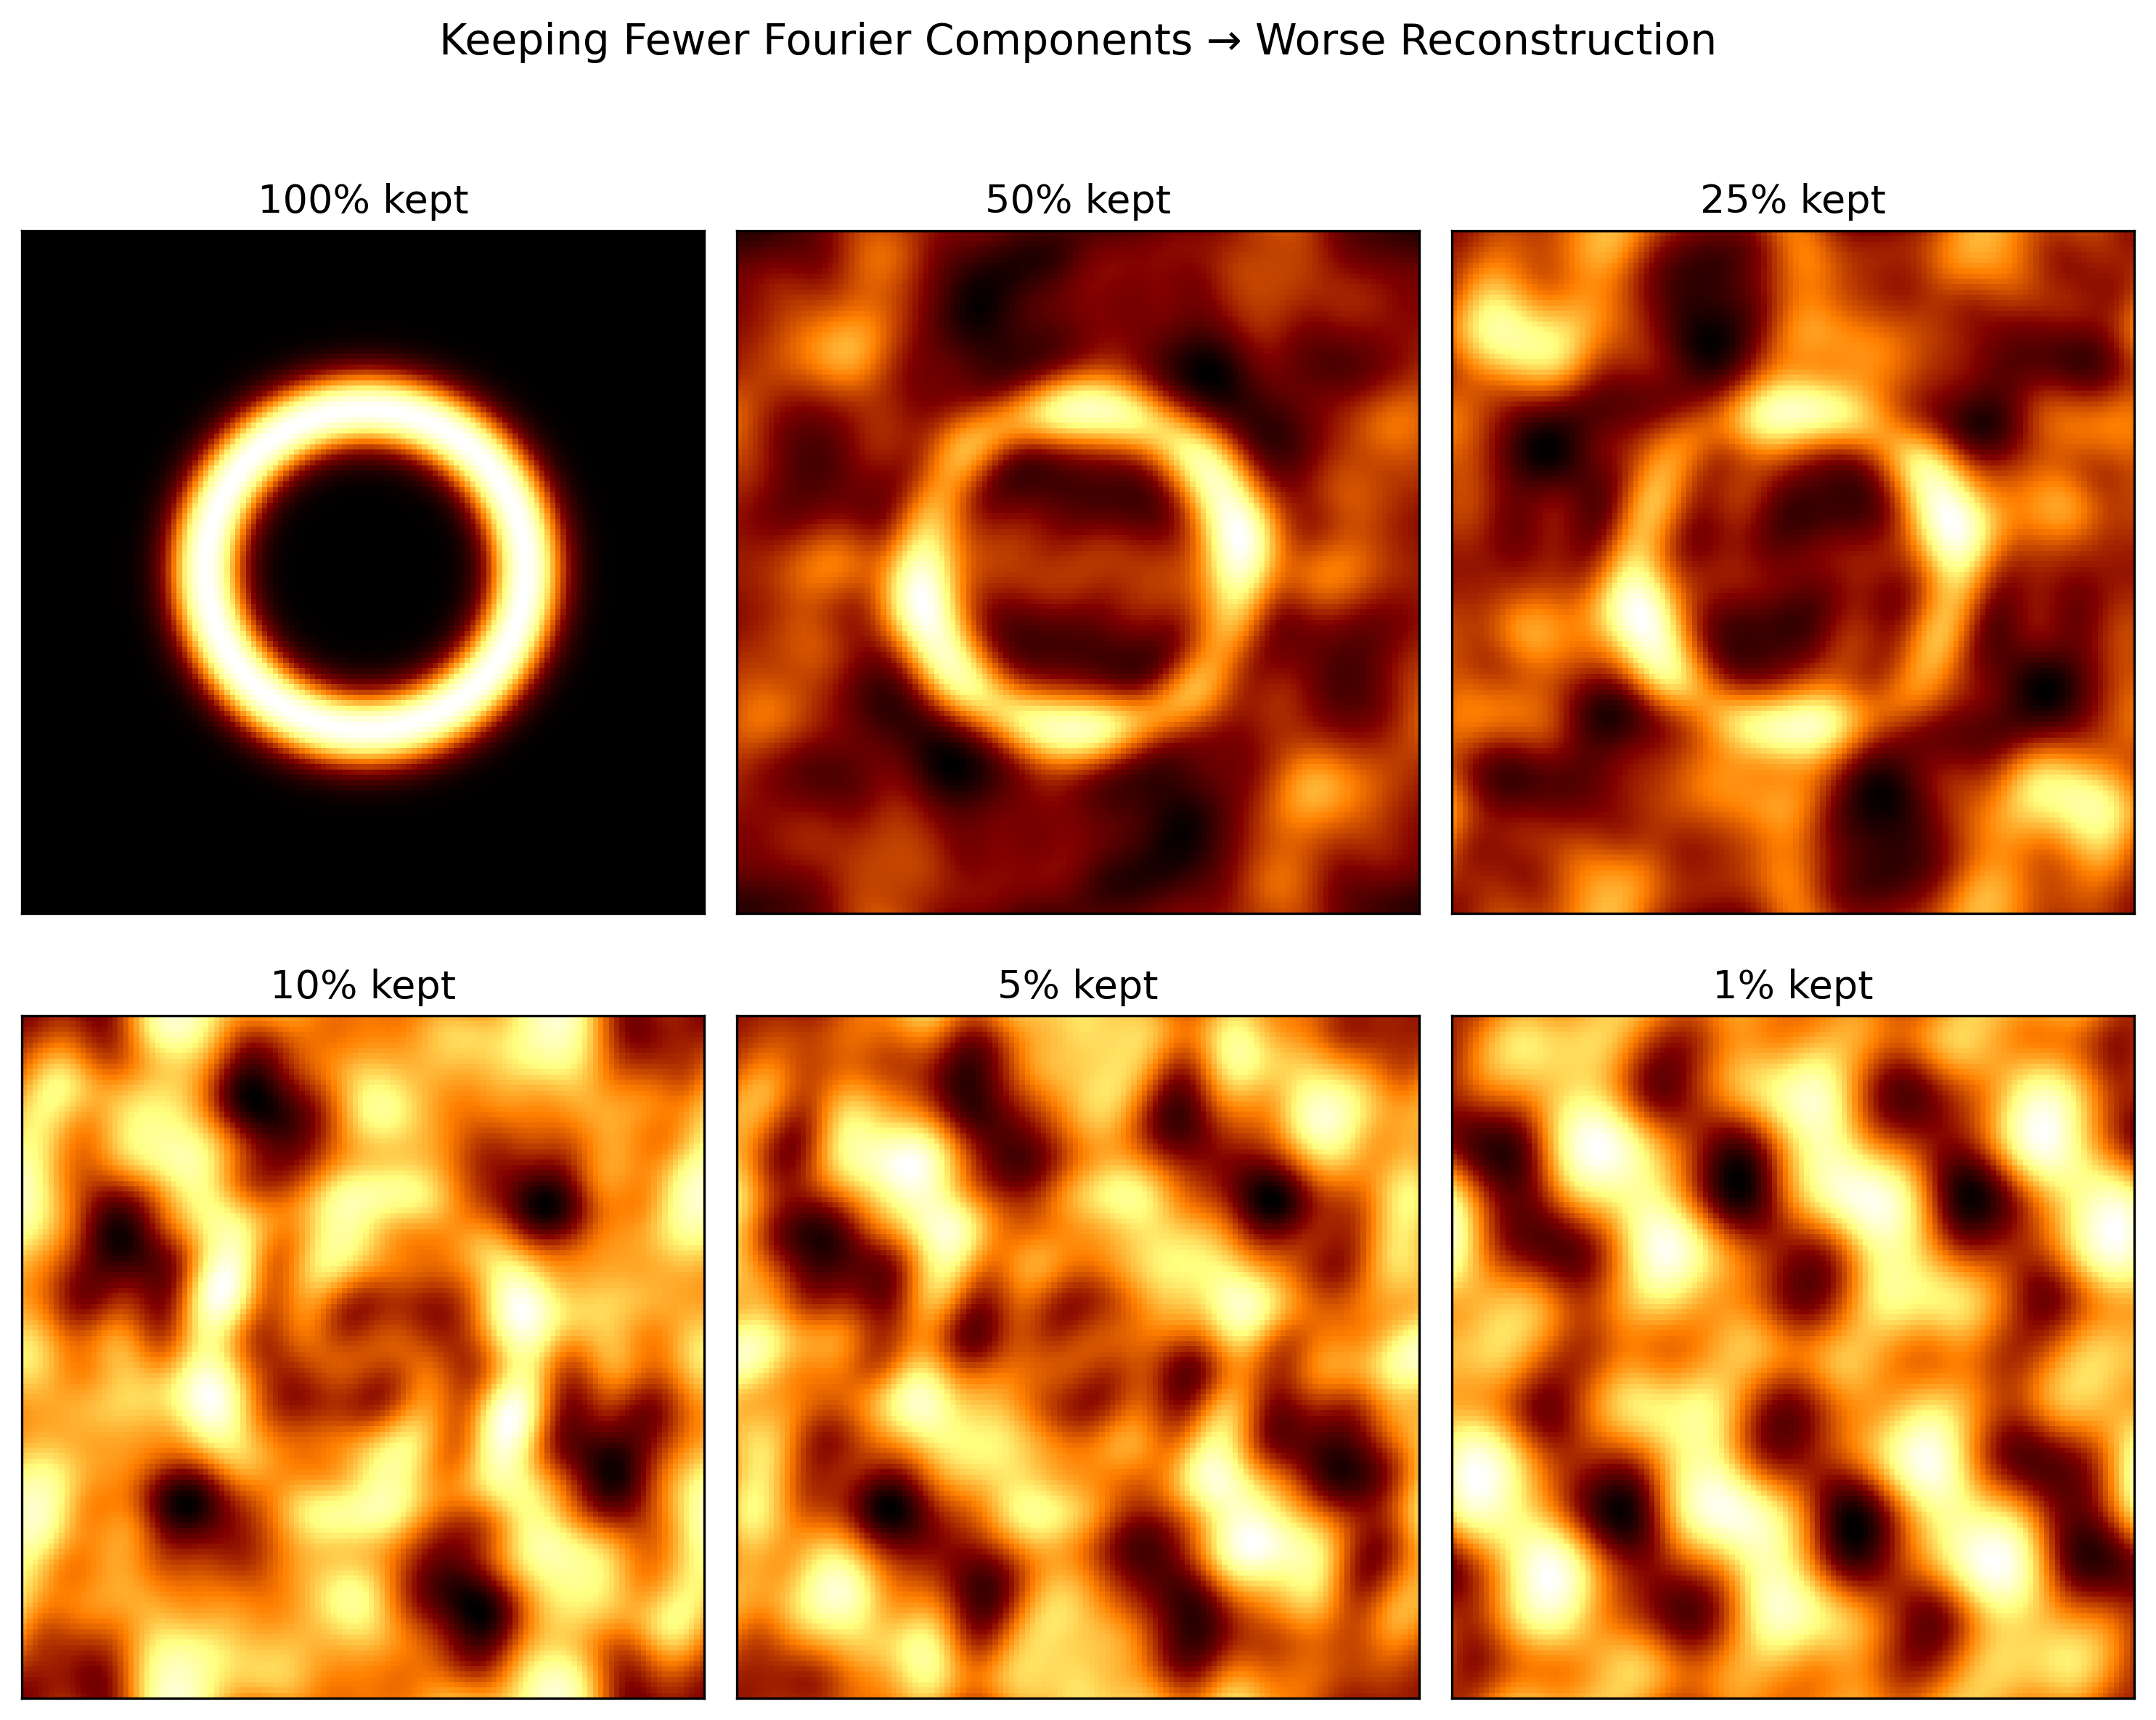

In [22]:
# Progressive removal: keep different fractions of Fourier components
fractions = [1.0, 0.50, 0.25, 0.10, 0.05, 0.01]

fig, axes = plt.subplots(2, 3, figsize=(10, 8))

for idx, frac in enumerate(fractions):
    ax = axes[idx // 3, idx % 3]
    
    # Keep a random fraction of Fourier components
    rng = np.random.RandomState(42)
    mask = rng.random_sample((N, N)) < frac
    # Always keep the DC component
    mask[N//2, N//2] = True
    
    filtered_fft = ring_fft * mask
    filtered_img = np.fft.ifft2(np.fft.ifftshift(filtered_fft)).real
    
    ax.imshow(filtered_img, cmap='afmhot', origin='lower')
    ax.set_title(f'{frac*100:.0f}% kept', fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Keeping Fewer Fourier Components \u2192 Worse Reconstruction',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**What do you notice?** As we keep fewer Fourier components, we lose resolution. The ring becomes noisy and eventually unrecognizable.

**This is exactly what happens in interferometry.** The Event Horizon Telescope doesn't measure all Fourier components. It measures a *tiny* fraction of them. And yet, the M87* image is sharp and clear. How?

---

## The Earth-Sized Telescope

To resolve a black hole shadow at angular size $\theta \sim 50\,\mu\text{as}$ (microarcseconds), you need a telescope with diameter:

$$D \sim \frac{\lambda}{\theta}$$

At the EHT observing wavelength $\lambda = 1.3\,\text{mm}$:

$$D \sim \frac{1.3 \times 10^{-3}\,\text{m}}{2.4 \times 10^{-10}\,\text{rad}} \approx 5{,}400\,\text{km} \sim \text{the diameter of Earth!}$$

No single dish this large exists. Instead, the **Event Horizon Telescope** links radio telescopes across the globe using **Very Long Baseline Interferometry (VLBI)**. Each pair of telescopes (a **baseline**) measures **one Fourier component** of the image.

The set of all measured Fourier components is called the **$u$-$v$ coverage**.

In [29]:
# Simulate simplified EHT-like u-v coverage
# Each pair of telescopes traces an elliptical arc as the Earth rotates

np.random.seed(42)

# Simplified station positions (inspired by real EHT sites)
stations = {
    'ALMA (Chile)':    (0.0, -23.0),
    'SMA (Hawaii)':    (-155.0, 19.0),
    'SMT (Arizona)':   (-111.0, 32.0),
    'JCMT (Hawaii)':   (-155.5, 19.8),
    'LMT (Mexico)':    (-97.0, 19.0),
    'IRAM (Spain)':    (-3.0, 37.0),
    'SPT (S. Pole)':   (0.0, -90.0),
    'NOEMA (France)':  (6.0, 44.0),
}

station_names = list(stations.keys())
station_coords = list(stations.values())

# Generate u-v tracks for each baseline
hour_angles = np.linspace(-4, 4, 40)  # hours of observation

all_u, all_v = [], []
baseline_tracks = []  # (u_track, v_track, label)

for i in range(len(station_names)):
    for j in range(i+1, len(station_names)):
        lon1, lat1 = station_coords[i]
        lon2, lat2 = station_coords[j]
        
        # Simplified baseline in wavelengths
        dx = (lon2 - lon1) * 100  # scale to realistic u-v range
        dy = (lat2 - lat1) * 100
        
        # Earth rotation synthesis: each baseline traces an ellipse
        cos_h = np.cos(hour_angles * np.pi / 12)
        sin_h = np.sin(hour_angles * np.pi / 12)
        
        u_track = dx * cos_h - dy * sin_h * 0.3
        v_track = dx * sin_h * 0.5 + dy * cos_h
        
        # Scale to fit within our image's frequency range
        scale = 0.003
        u_track *= scale
        v_track *= scale
        
        label = f"{station_names[i][:4]}-{station_names[j][:4]}"
        baseline_tracks.append((u_track, v_track, label))
        all_u.extend(u_track)
        all_v.extend(v_track)
        # Also add conjugate points (V(-u,-v) = V*(u,v))
        all_u.extend(-u_track)
        all_v.extend(-v_track)

all_u = np.array(all_u)
all_v = np.array(all_v)

print(f"Number of baselines: {len(baseline_tracks)}")
print(f"Total u-v points (with conjugates): {len(all_u)}")

Number of baselines: 28
Total u-v points (with conjugates): 2240


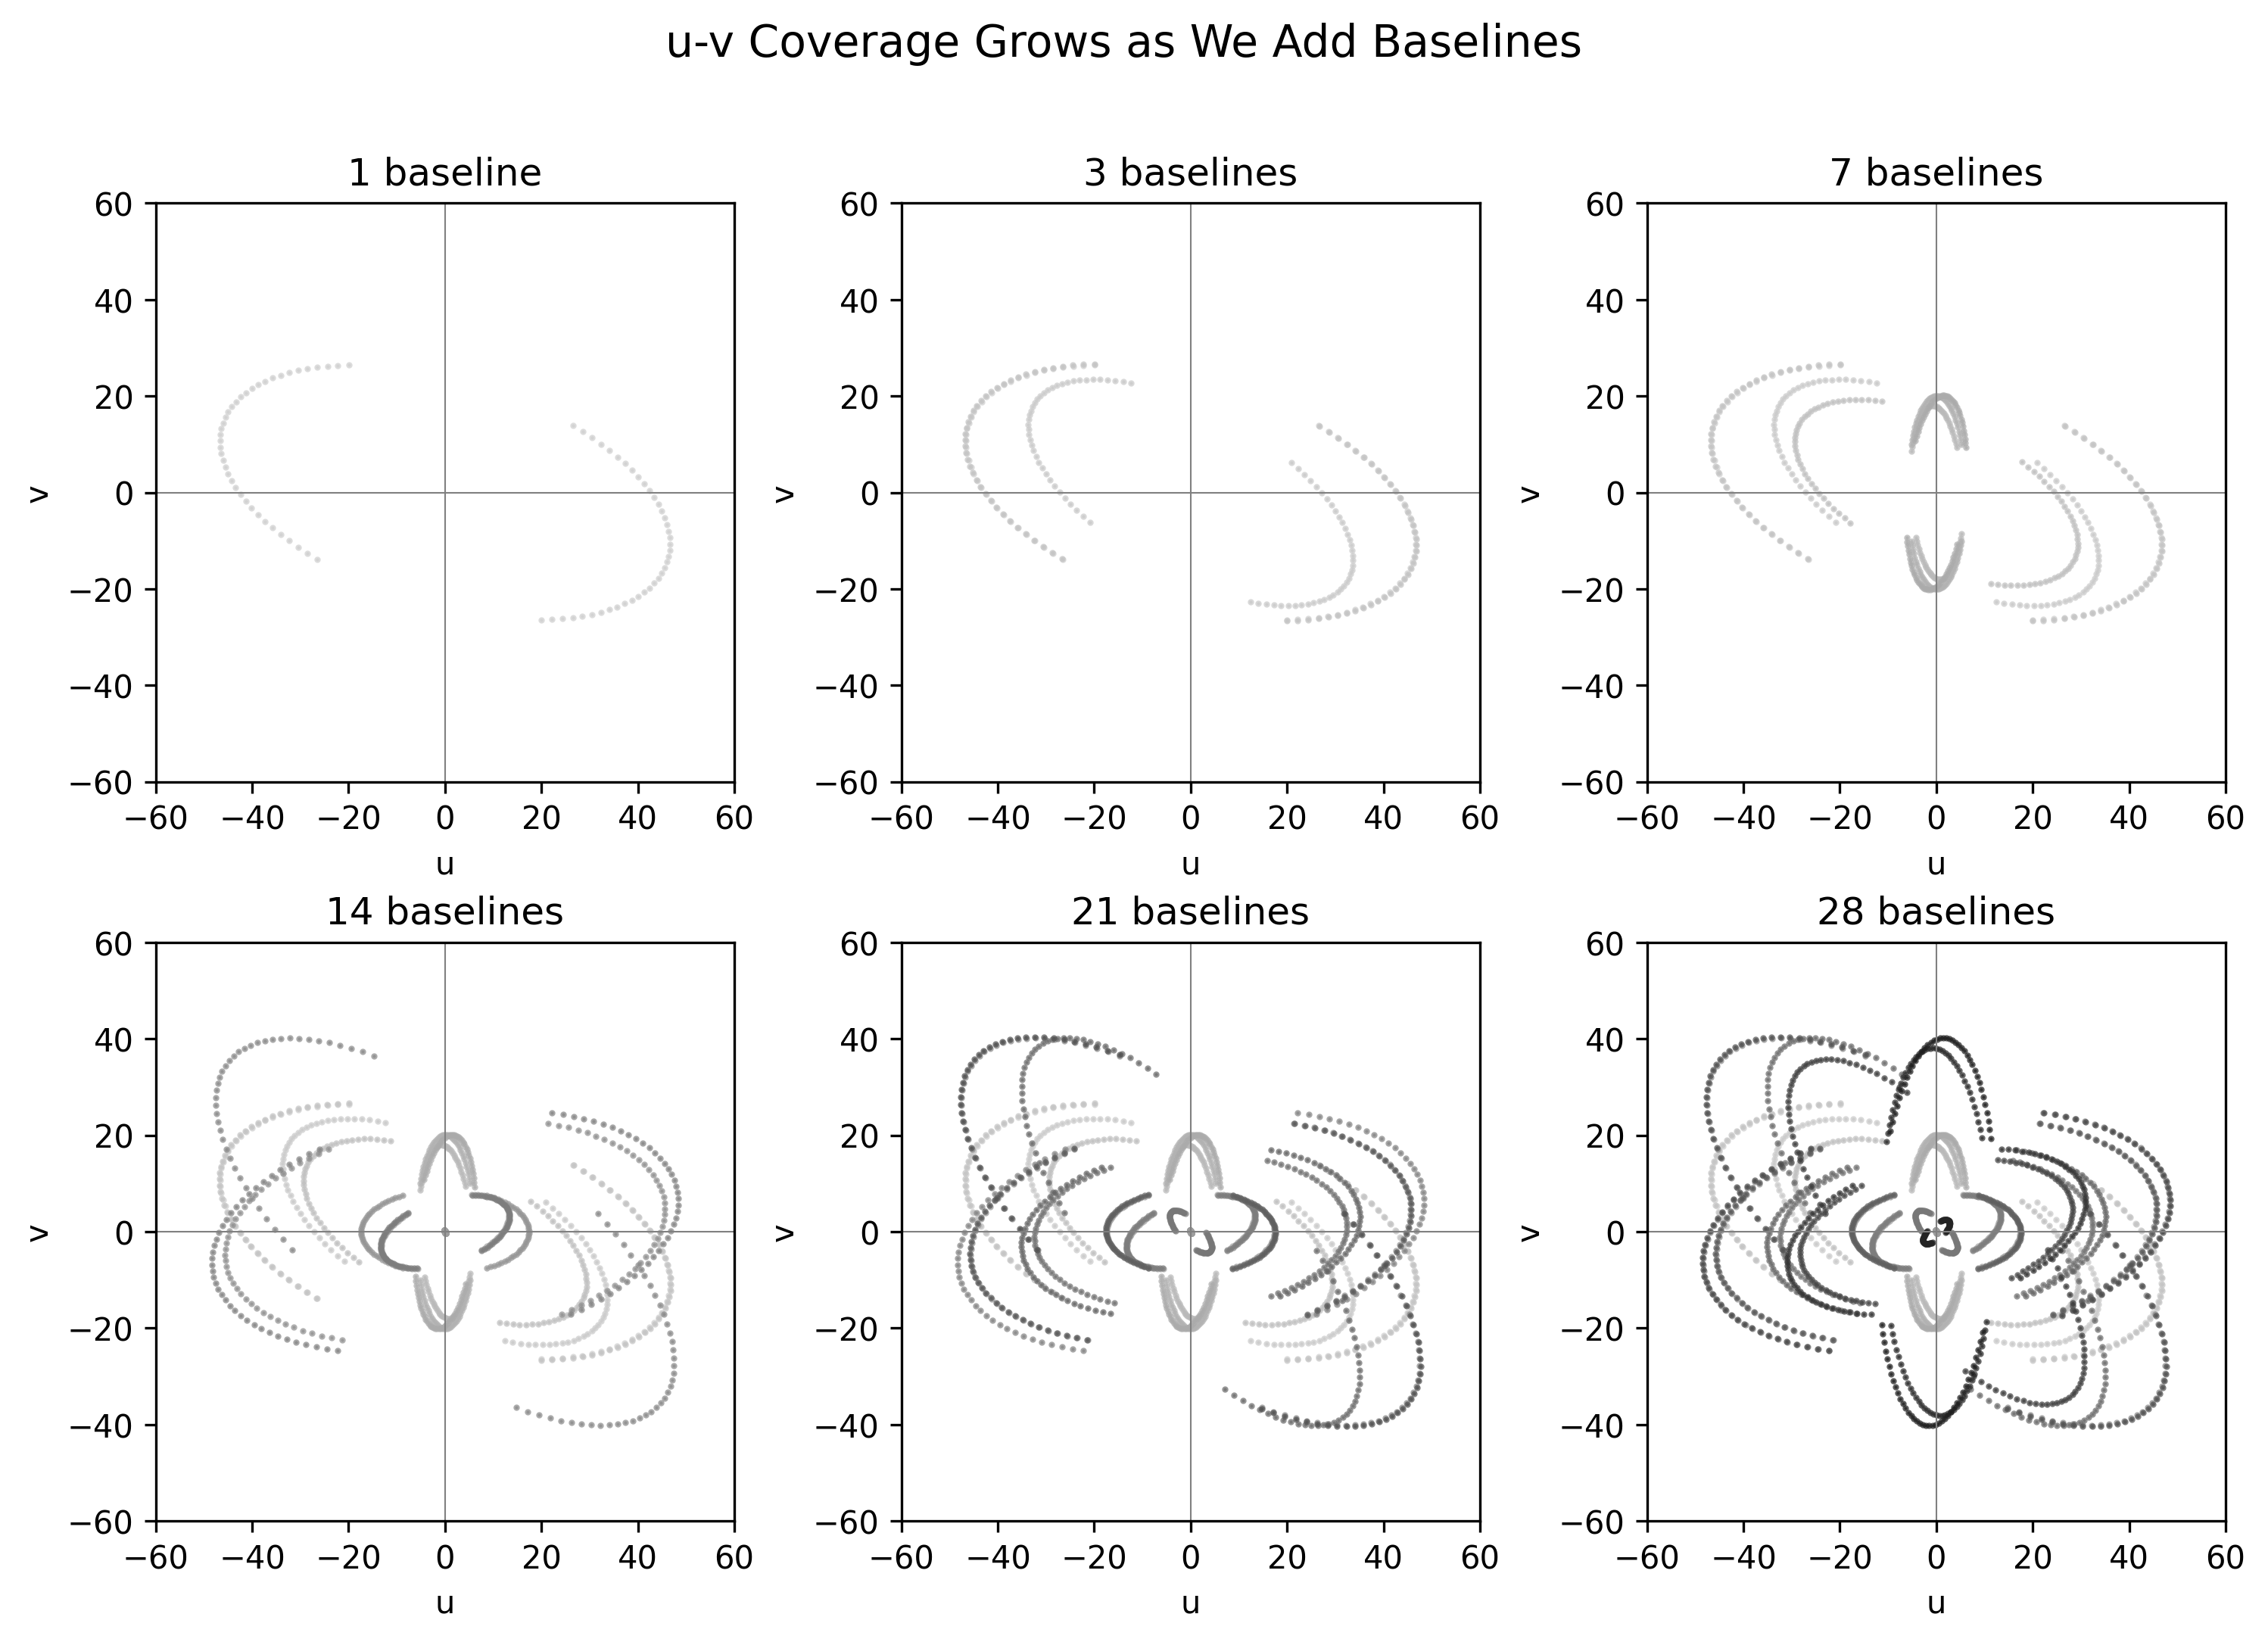

In [31]:
# Progressive u-v coverage: watch the coverage grow as we add baselines

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
n_show = [1, 3, 7, 14, 21, len(baseline_tracks)]

colors = plt.cm.Greys(np.linspace(0.3, 0.9, len(baseline_tracks)))

for idx, n_baselines in enumerate(n_show):
    ax = axes[idx // 3, idx % 3]
    
    for k in range(n_baselines):
        u_t, v_t, label = baseline_tracks[k]
        ax.plot(u_t, v_t, '.', color=colors[k], markersize=2, alpha=0.7)
        ax.plot(-u_t, -v_t, '.', color=colors[k], markersize=2, alpha=0.7)
    
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_aspect('equal')
    ax.set_title(f'{n_baselines} baseline{"s" if n_baselines > 1 else ""}', fontsize=12)
    ax.set_xlabel('u', fontsize=10)
    ax.set_ylabel('v', fontsize=10)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)

plt.suptitle('u-v Coverage Grows as We Add Baselines', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

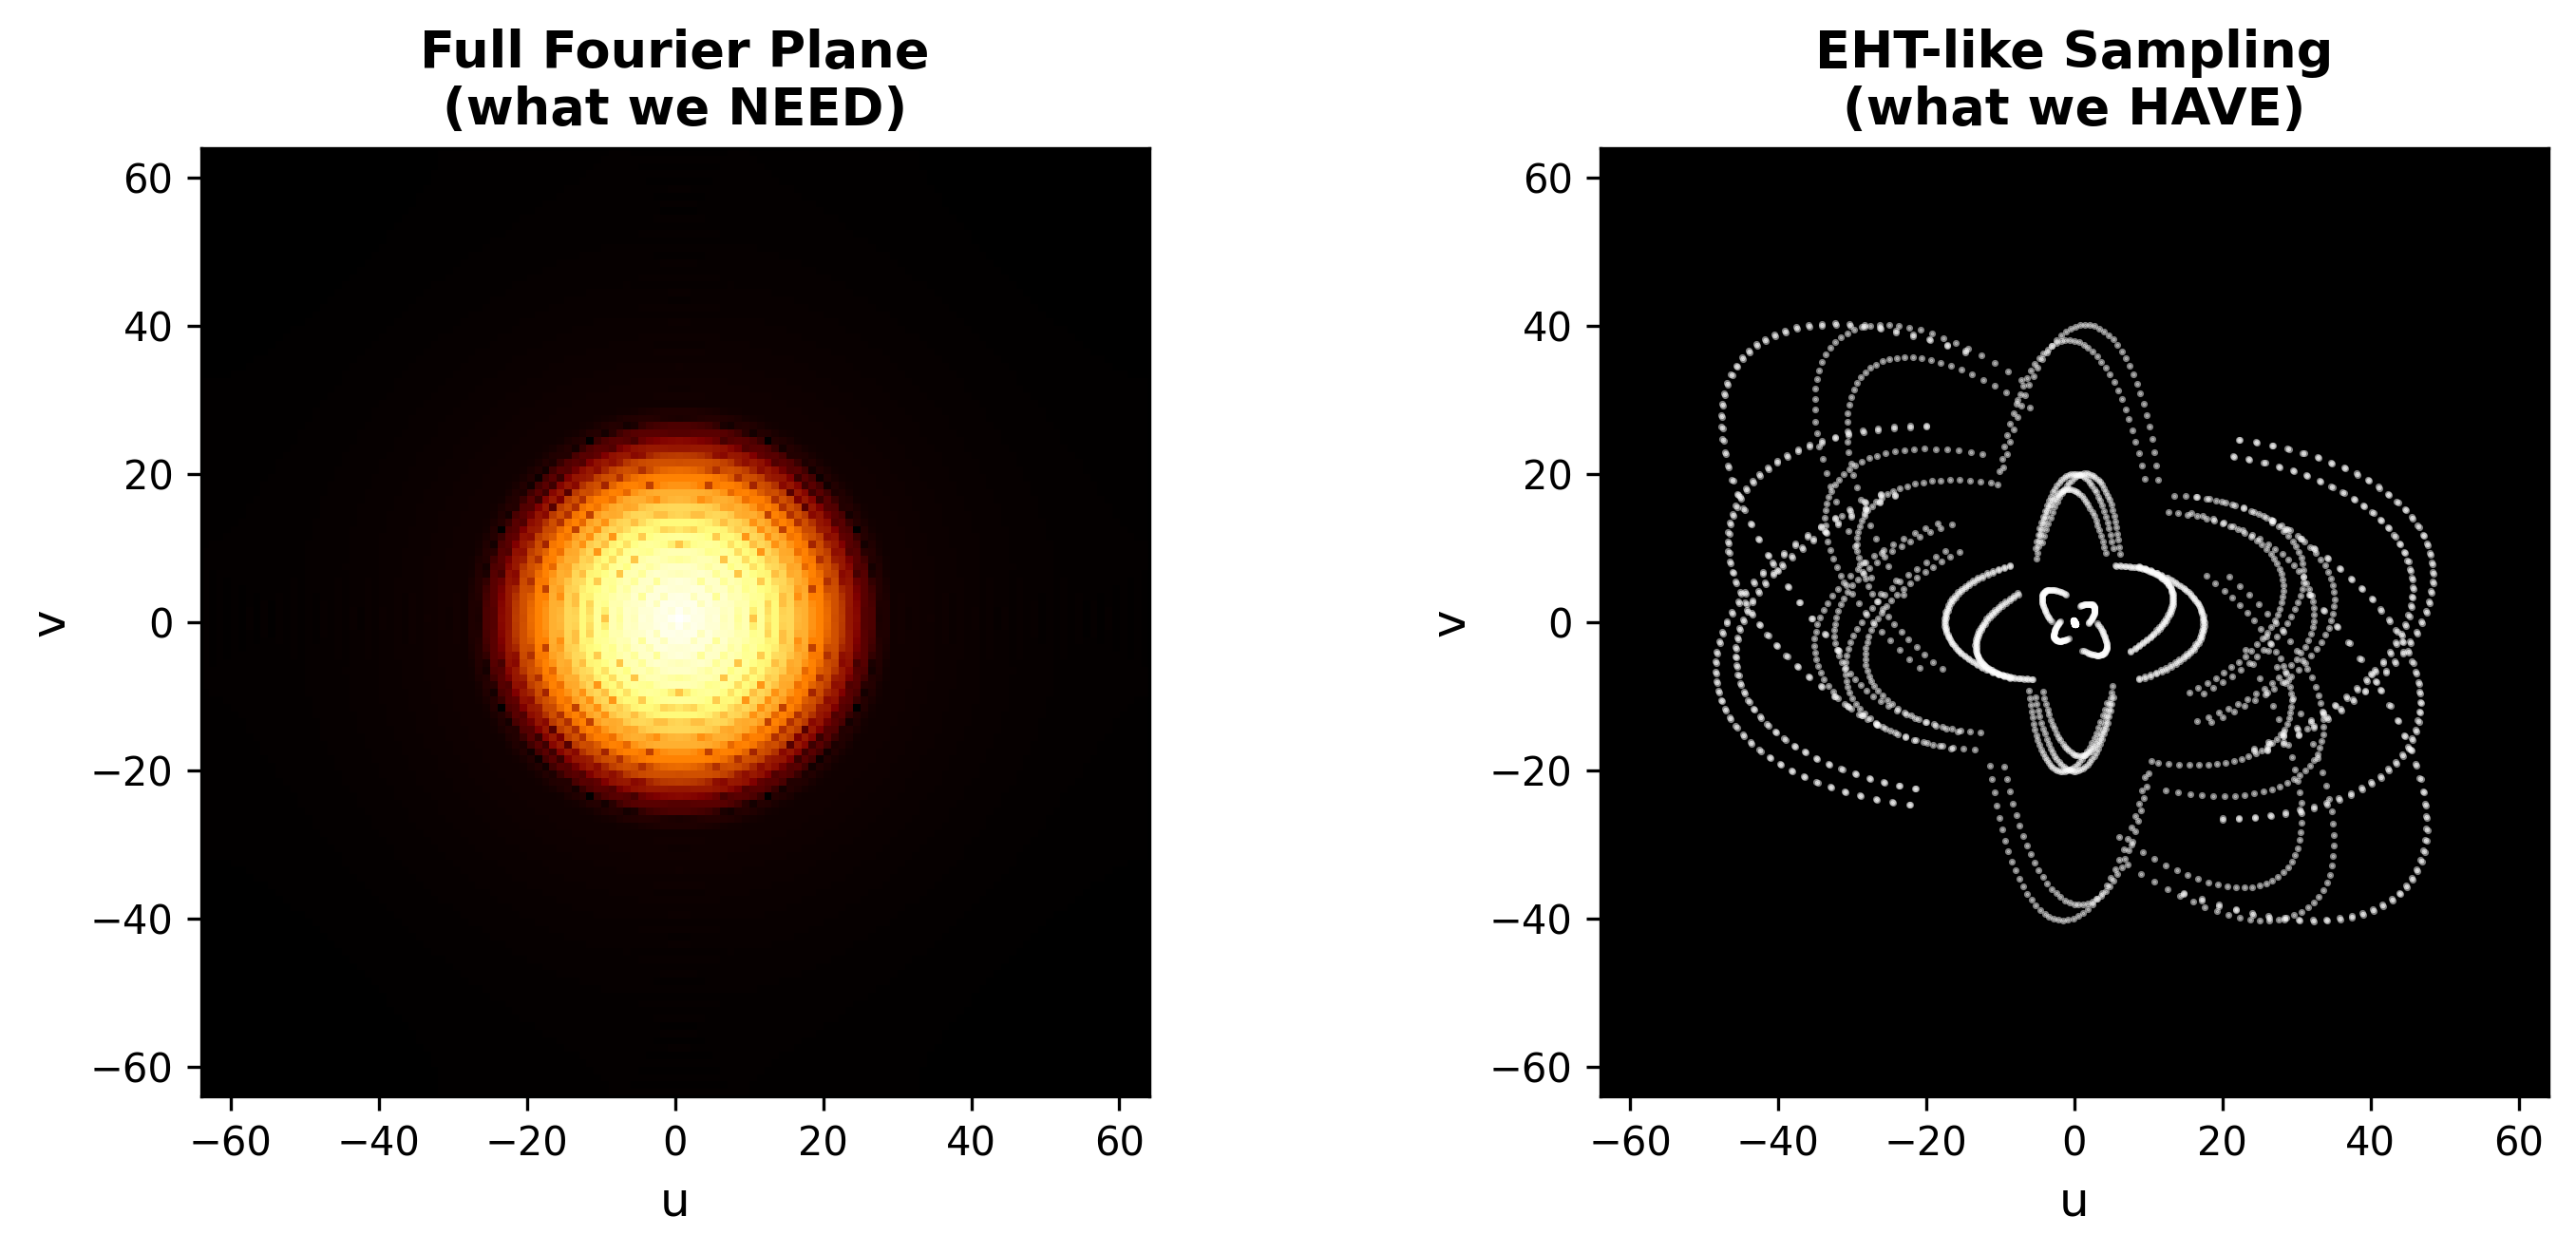

Full Fourier plane: 16,384 points
EHT-like sampling:  2,240 points
That's only 13.67% of the full Fourier plane!


In [32]:
# Compare: full Fourier plane vs. EHT-like sparse sampling

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Full Fourier plane
axes[0].imshow(np.log10(np.abs(ring_fft) + 1e-12), cmap='afmhot', origin='lower',
               extent=[-N//2, N//2, -N//2, N//2])
axes[0].set_title('Full Fourier Plane\n(what we NEED)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('u', fontsize=12)
axes[0].set_ylabel('v', fontsize=12)

# Sparse EHT-like sampling
axes[1].set_facecolor('black')
axes[1].scatter(all_u, all_v, c='white', s=0.5, alpha=0.5)
axes[1].set_xlim(-N//2, N//2)
axes[1].set_ylim(-N//2, N//2)
axes[1].set_aspect('equal')
axes[1].set_title('EHT-like Sampling\n(what we HAVE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('u', fontsize=12)
axes[1].set_ylabel('v', fontsize=12)

plt.tight_layout()
plt.show()

total_possible = N * N
total_measured = len(all_u)
print(f"Full Fourier plane: {total_possible:,} points")
print(f"EHT-like sampling:  {total_measured:,} points")
print(f"That's only {total_measured/total_possible*100:.2f}% of the full Fourier plane!")

**We measure less than 0.1% of the Fourier components.** The vast majority of the Fourier plane is empty. Yet we need to reconstruct a complete image.

---

## C The Dirty Image

What if we just **naively** inverse-transform the data we have, filling in zeros where we have no measurements? This is called the **dirty image**.

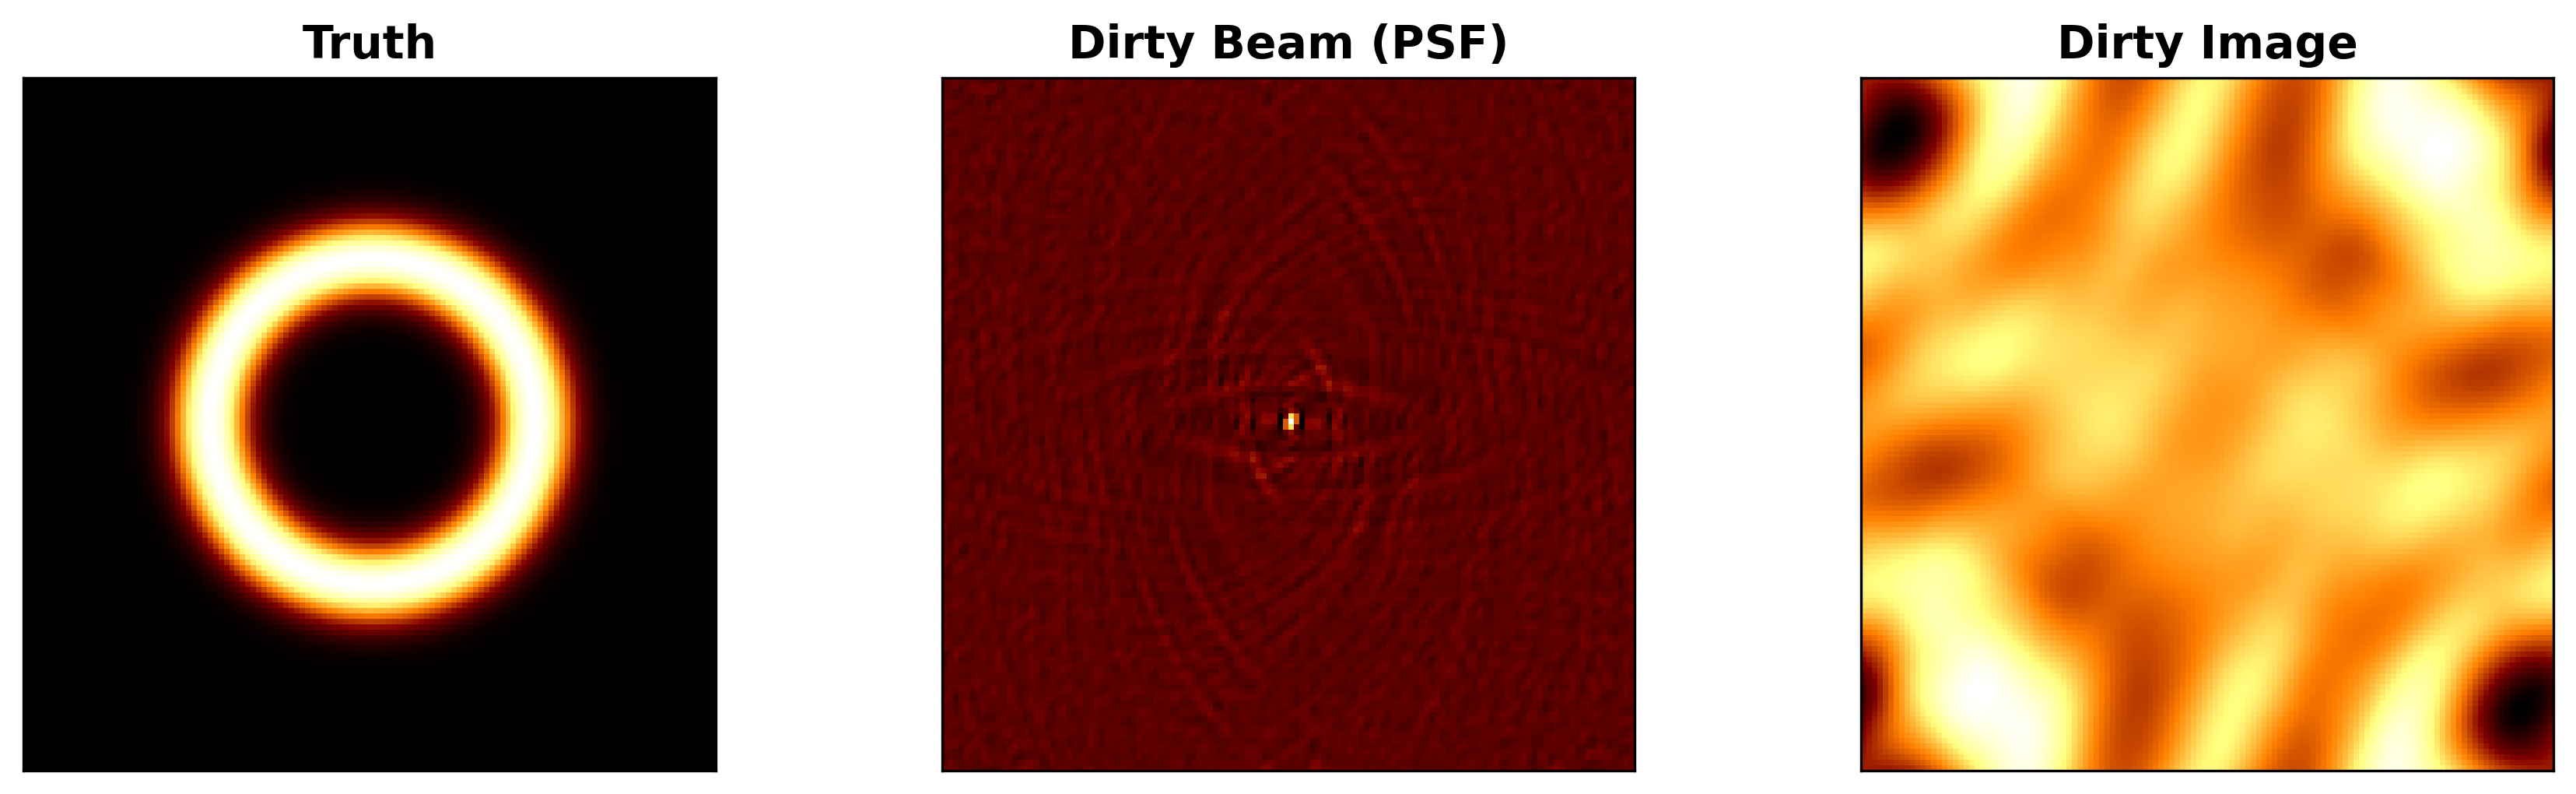

The naive approach fails. The dirty image is full of artifacts.
We need something smarter — we need gradient descent.


In [33]:
# Create a sampling mask on the Fourier grid from our u-v points
sampling_mask = np.zeros((N, N))
for u_val, v_val in zip(all_u, all_v):
    ui = int(np.round(u_val)) + N // 2
    vi = int(np.round(v_val)) + N // 2
    if 0 <= ui < N and 0 <= vi < N:
        sampling_mask[vi, ui] = 1.0

# Dirty beam = inverse FFT of the sampling function (the PSF)
dirty_beam = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(sampling_mask))).real

# Dirty image = inverse FFT of the sampled visibilities
sampled_vis = ring_fft * sampling_mask
dirty_image = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(sampled_vis))).real

# Normalize for display
dirty_beam_disp = dirty_beam / np.max(np.abs(dirty_beam))
dirty_image_disp = dirty_image / np.max(np.abs(dirty_image)) if np.max(np.abs(dirty_image)) > 0 else dirty_image

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].imshow(ring, cmap='afmhot', origin='lower')
axes[0].set_title('Truth', fontsize=14, fontweight='bold')

axes[1].imshow(dirty_beam_disp, cmap='afmhot', origin='lower')
axes[1].set_title('Dirty Beam (PSF)', fontsize=14, fontweight='bold')

axes[2].imshow(dirty_image_disp, cmap='afmhot', origin='lower')
axes[2].set_title('Dirty Image', fontsize=14, fontweight='bold')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

print("The naive approach fails. The dirty image is full of artifacts.")
print("We need something smarter — we need gradient descent.")

---

# Image Reconstruction = Gradient Descent

---

Remember our **ML recipe** from Notebook 1?

| Step | Polynomial Fitting | Image Reconstruction |
|------|-------------------|---------------------|
| **Model** | $f(x) = \sum a_k x^k$ | $V(u,v) = \text{DFT}[I(x,y)]$ |
| **Loss** | $\sum (y_i - f(x_i))^2$ | $\chi^2 + \text{regularization}$ |
| **Gradient** | `jax.grad(loss)` | `jax.grad(loss)` |
| **Update** | $a \leftarrow a - \eta \nabla L$ | $I \leftarrow I - \eta \nabla L$ |

**Same recipe. Same `jax.grad`. Different problem.**

---

## The Forward Model |  Full FFT

Our forward model takes an image and computes what we would measure with complete Fourier coverage. Each visibility is a Fourier component of the image:

$$\hat{I}(u,v) = \text{FFT}[I(x,y)]$$

The forward model is simply `jnp.fft.fft2` — the same FFT we used in Section 1 to visualize the Fourier transform.

We'll work at $N = 64$ (a 64 $\times$ 64 image) for a clearer ring structure. First we'll show that gradient descent can recover the ring from the **complete** FFT (a well-determined problem). Then we'll see what happens when data is **sparse** (like the EHT).

In [34]:
N = 64  # 64x64 for clearer ring structure

In [35]:
# Create ground truth ring at N=64
y64, x64 = np.mgrid[-N//2:N//2, -N//2:N//2]
r64 = np.sqrt(x64**2 + y64**2).astype(float)
ring64 = np.exp(-((r64 - 20)**2) / (2 * 4.0**2))
ring64 = ring64 / ring64.sum()
ring64_jax = jnp.array(ring64, dtype=jnp.float32)

# "Observe" the full Fourier transform with noise
ring_fft_obs = jnp.fft.fft2(ring64_jax)
sigma = 1e-4
noise = sigma * (np.random.randn(N, N) + 1j * np.random.randn(N, N)).astype(np.complex64)
obs_fft = ring_fft_obs + jnp.array(noise)

print(f"Image: {N}x{N} = {N*N} pixels")
print(f"Fourier measurements: {N*N} (complete coverage)")
print(f"This is a well-determined problem — same number of equations as unknowns.")

Image: 64x64 = 4096 pixels
Fourier measurements: 4096 (complete coverage)
This is a well-determined problem — same number of equations as unknowns.


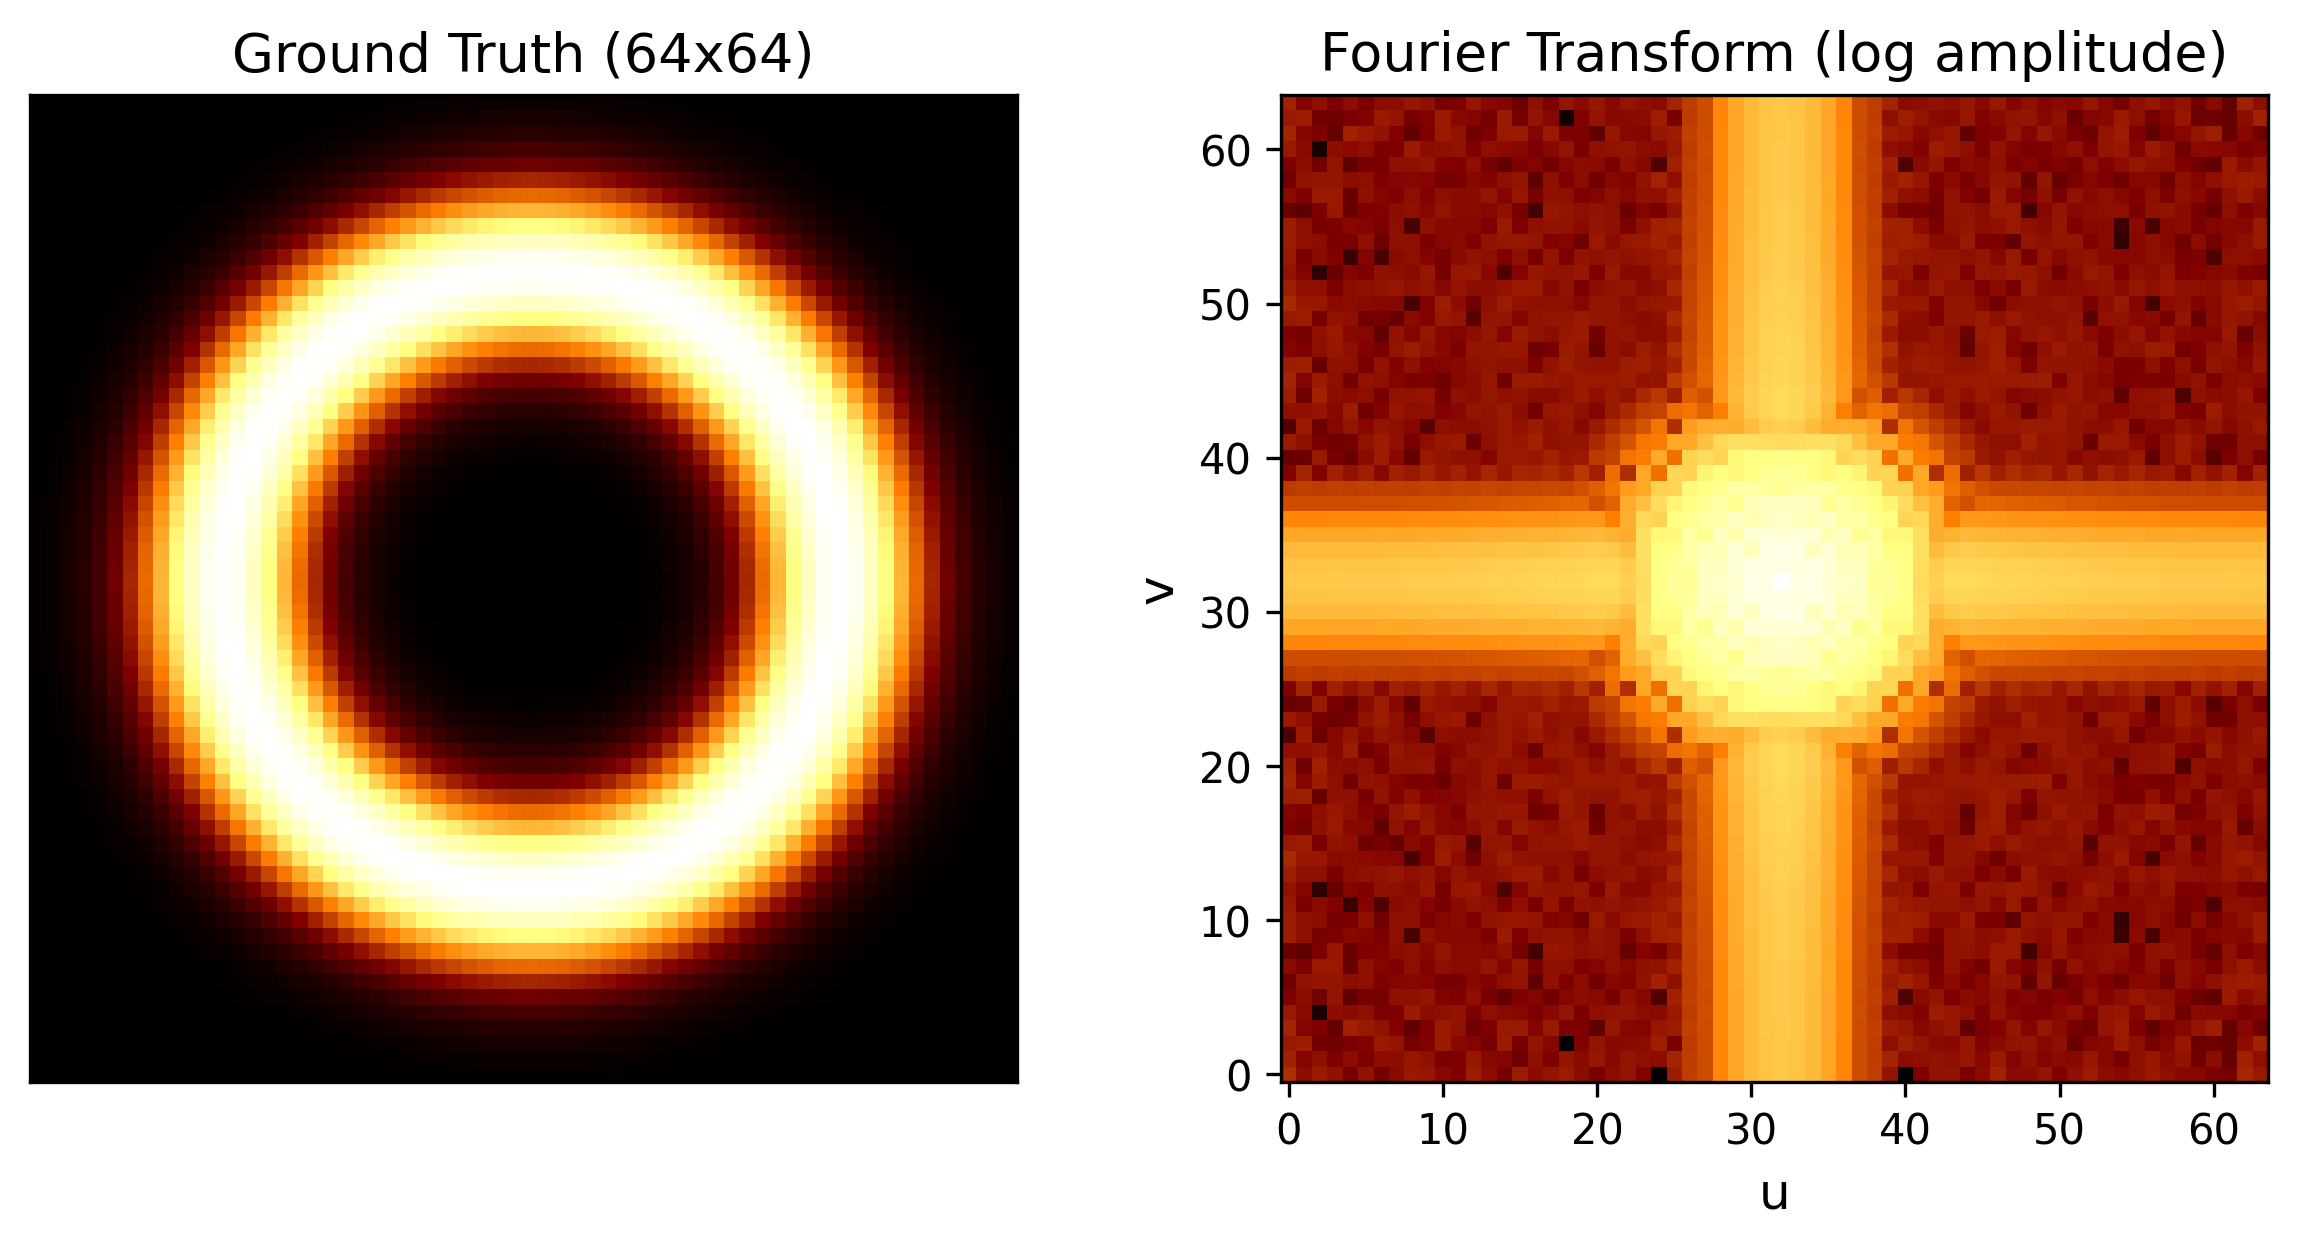

In [40]:
# Visualize the ground truth and its Fourier transform

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(ring64, cmap='afmhot', origin='lower')
axes[0].set_title('Ground Truth (64x64)', fontsize=13)
axes[0].set_xticks([])
axes[0].set_yticks([])

ring64_fft_shifted = np.fft.fftshift(np.array(ring_fft_obs))
axes[1].imshow(np.log10(np.abs(ring64_fft_shifted) + 1e-12), cmap='afmhot', origin='lower')
axes[1].set_title('Fourier Transform (log amplitude)', fontsize=13)
axes[1].set_xlabel('u', fontsize=12)
axes[1].set_ylabel('v', fontsize=12)

plt.tight_layout()
plt.show()

---

## The Loss Function

Because we have fewer measurements than unknowns, the data alone can't determine a unique image. We need **regularization** — prior beliefs about what a good image looks like.

Our loss function has three components.

---

### Component 1: Chi-squared (Data Fidelity)

How well does our model image explain the measured data?

$$\chi^2 = \frac{1}{M}\sum_{k=1}^{M} \frac{|V_k^{\text{model}} - V_k^{\text{obs}}|^2}{\sigma_k^2}$$

If $\chi^2 \approx 1$, we fit the data to within the noise. If $\chi^2 \gg 1$, we're underfitting. If $\chi^2 \ll 1$, we're overfitting noise.

In [37]:
def chi_squared(image, obs_fft, sigma):
    """Data fidelity: how well does the model match observations?"""
    model_fft = jnp.fft.fft2(image)
    return jnp.mean(jnp.abs(model_fft - obs_fft)**2) / sigma**2

### Component 2: Total Variation Regularization

We prefer images that are **smooth** — no wild pixel-to-pixel fluctuations. Total Variation measures the "roughness" of an image:

$$\text{TV}(I) = \sum_{x,y}\sqrt{(\Delta_x I)^2 + (\Delta_y I)^2 + \epsilon}$$

where $\Delta_x I$ and $\Delta_y I$ are finite differences (gradients) along each axis. TV is **low** for smooth images and **high** for noisy or speckled images.

In [38]:
def total_variation(image):
    """Total variation: penalizes rough/noisy images."""
    dx = jnp.diff(image, axis=1)
    dy = jnp.diff(image, axis=0)
    return jnp.sum(jnp.sqrt(dx[:-1,:]**2 + dy[:,:-1]**2 + 1e-10))

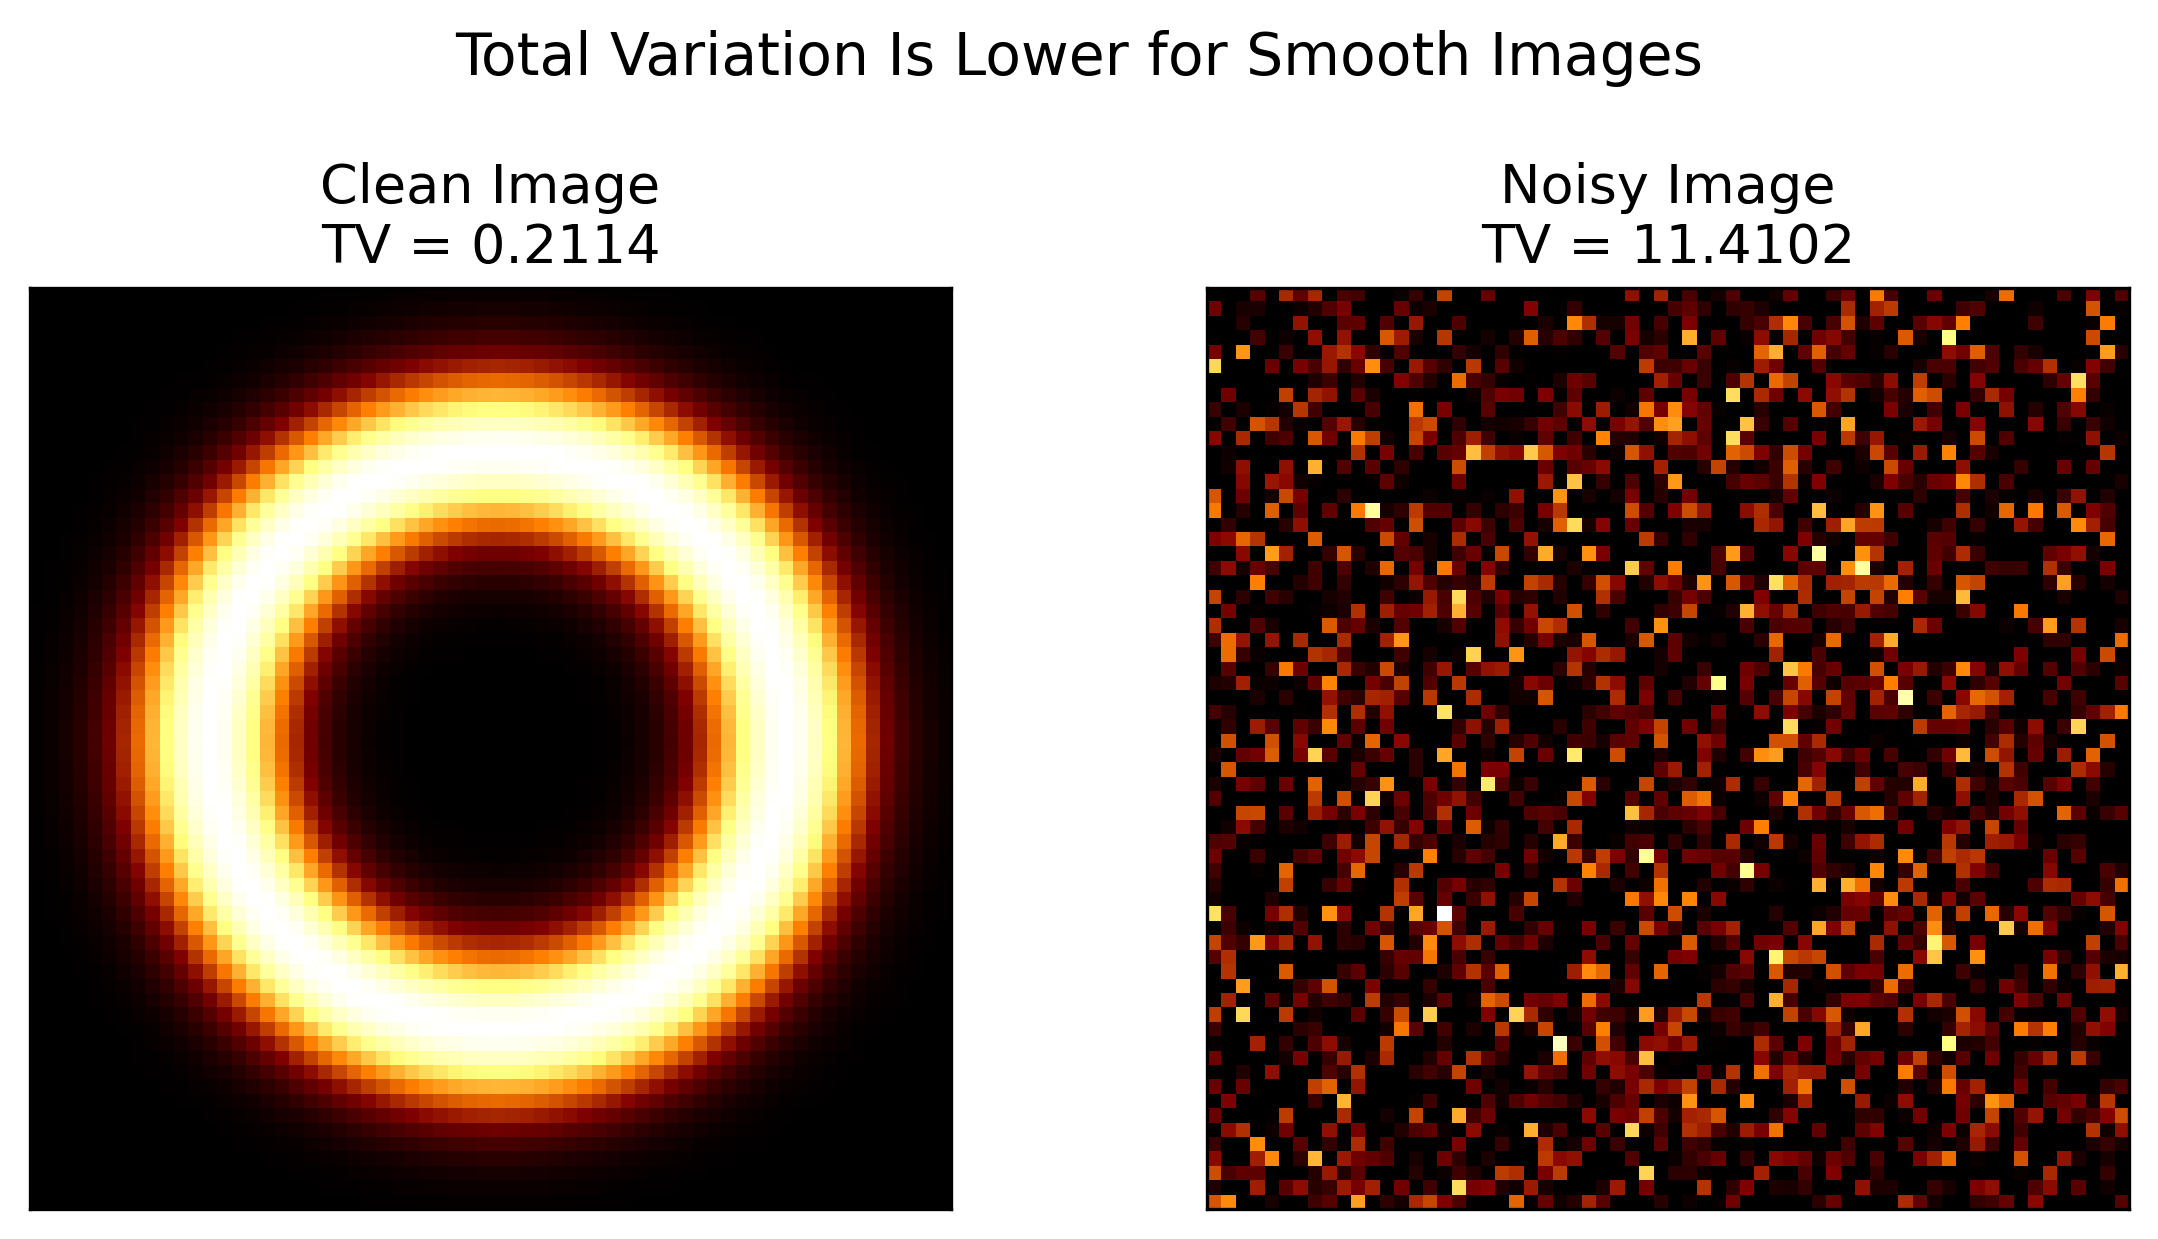

TV (clean) = 0.2114
TV (noisy) = 11.4102

TV acts as a 'smoothness score' — minimizing it encourages smooth images.


In [42]:
# Visual intuition: TV as a "smoothness score"

# Create a noisy image and a clean image
clean_img = jnp.array(ring64, dtype=jnp.float32)
noisy_img = clean_img + 0.003 * jax.random.normal(jax.random.PRNGKey(0), clean_img.shape)
noisy_img = jnp.clip(noisy_img, 0, None)

tv_clean = float(total_variation(clean_img))
tv_noisy = float(total_variation(noisy_img))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(np.array(clean_img), cmap='afmhot', origin='lower')
axes[0].set_title(f'Clean Image\nTV = {tv_clean:.4f}', fontsize=13)
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].imshow(np.array(noisy_img), cmap='afmhot', origin='lower')
axes[1].set_title(f'Noisy Image\nTV = {tv_noisy:.4f}', fontsize=13)
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.suptitle('Total Variation Is Lower for Smooth Images', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"TV (clean) = {tv_clean:.4f}")
print(f"TV (noisy) = {tv_noisy:.4f}")
print(f"\nTV acts as a 'smoothness score' — minimizing it encourages smooth images.")

### Component 3: Maximum Entropy

We can also encourage images with **maximum entropy** — spreading flux as uniformly as possible unless the data demands otherwise:

$$S(I) = -\sum_{x,y} I(x,y) \ln I(x,y)$$

(We won't use this in our reconstruction below, but it's a key regularizer used in real EHT imaging.)

### The Combined Loss

Our full loss function balances **data fidelity** (fit the measurements) with **regularization** (prefer smooth, physical images) and a **flux constraint** (total brightness is conserved):

$$\mathcal{L} = \chi^2 + \lambda_{\text{TV}} \cdot \text{TV}(I) + \lambda_{\text{flux}}\left(\sum I - F_0\right)^2$$

In [50]:
def imaging_loss(img_flat, obs_fft, sigma, lam_tv=0.001):
    """Combined loss: data fidelity + TV regularization.
    
    We optimize pixel values directly, using clipping for positivity.
    """
    image = img_flat.reshape(N, N)
    
    # Data fidelity: chi-squared via FFT
    model_fft = jnp.fft.fft2(image)
    chi2 = jnp.mean(jnp.abs(model_fft - obs_fft)**2)
    
    # Regularization: Total Variation
    tv = lam_tv * total_variation(image)
    
    return chi2 + tv

---

## Step 2.3: Gradient Descent Reconstruction


We start from a **uniform gray image**, no prior knowledge of the ring, no template, nothing. `jax.grad` will compute gradients through the *entire* pipeline: Fourier transforms, complex arithmetic, absolute values, square roots, **everything**.

Then gradient descent will sculpt the image, pixel by pixel, until a ring *emerges from the noise*.

In [51]:
# jax.grad gives us gradients through the ENTIRE pipeline
# — FFT, complex arithmetic, absolute values — everything!
grad_fn = jax.jit(jax.grad(imaging_loss))
loss_fn = jax.jit(imaging_loss)

# Start from a flat uniform image
img = jnp.ones(N * N, dtype=jnp.float32) / (N * N)

# Adam optimizer (a smarter version of gradient descent with momentum)
lr = 0.0001
beta1, beta2, eps = 0.9, 0.999, 1e-8
m = jnp.zeros_like(img)
v_adam = jnp.zeros_like(img)

n_steps = 500
losses = []
snapshots = {}
snapshot_steps = [0, 20, 50, 150, 500]

for step in range(1, n_steps + 1):
    if step in snapshot_steps or step == 1:
        snapshots[step if step > 1 else 0] = np.array(jnp.clip(img, 0, None).reshape(N, N))
    
    loss_val = loss_fn(img, obs_fft, sigma)
    g = grad_fn(img, obs_fft, sigma)
    
    # Adam update (gradient descent with adaptive learning rate)
    m = beta1 * m + (1 - beta1) * g
    v_adam = beta2 * v_adam + (1 - beta2) * g**2
    m_hat = m / (1 - beta1**step)
    v_hat = v_adam / (1 - beta2**step)
    img = jnp.clip(img - lr * m_hat / (jnp.sqrt(v_hat) + eps), 0, None)
    
    losses.append(float(loss_val))

# Store final snapshot
snapshots[n_steps] = np.array(jnp.clip(img, 0, None).reshape(N, N))

print(f"Initial loss: {losses[0]:.6f}")
print(f"Final loss:   {losses[-1]:.6f}")
print(f"\nReconstruction complete in {n_steps} steps!")

Initial loss: 0.000358
Final loss:   0.000179

Reconstruction complete in 500 steps!


### Watch the ring EMERGE

From a featureless gray image, gradient descent sculpts the reconstruction — finding the image most consistent with our sparse Fourier measurements AND our smoothness prior.

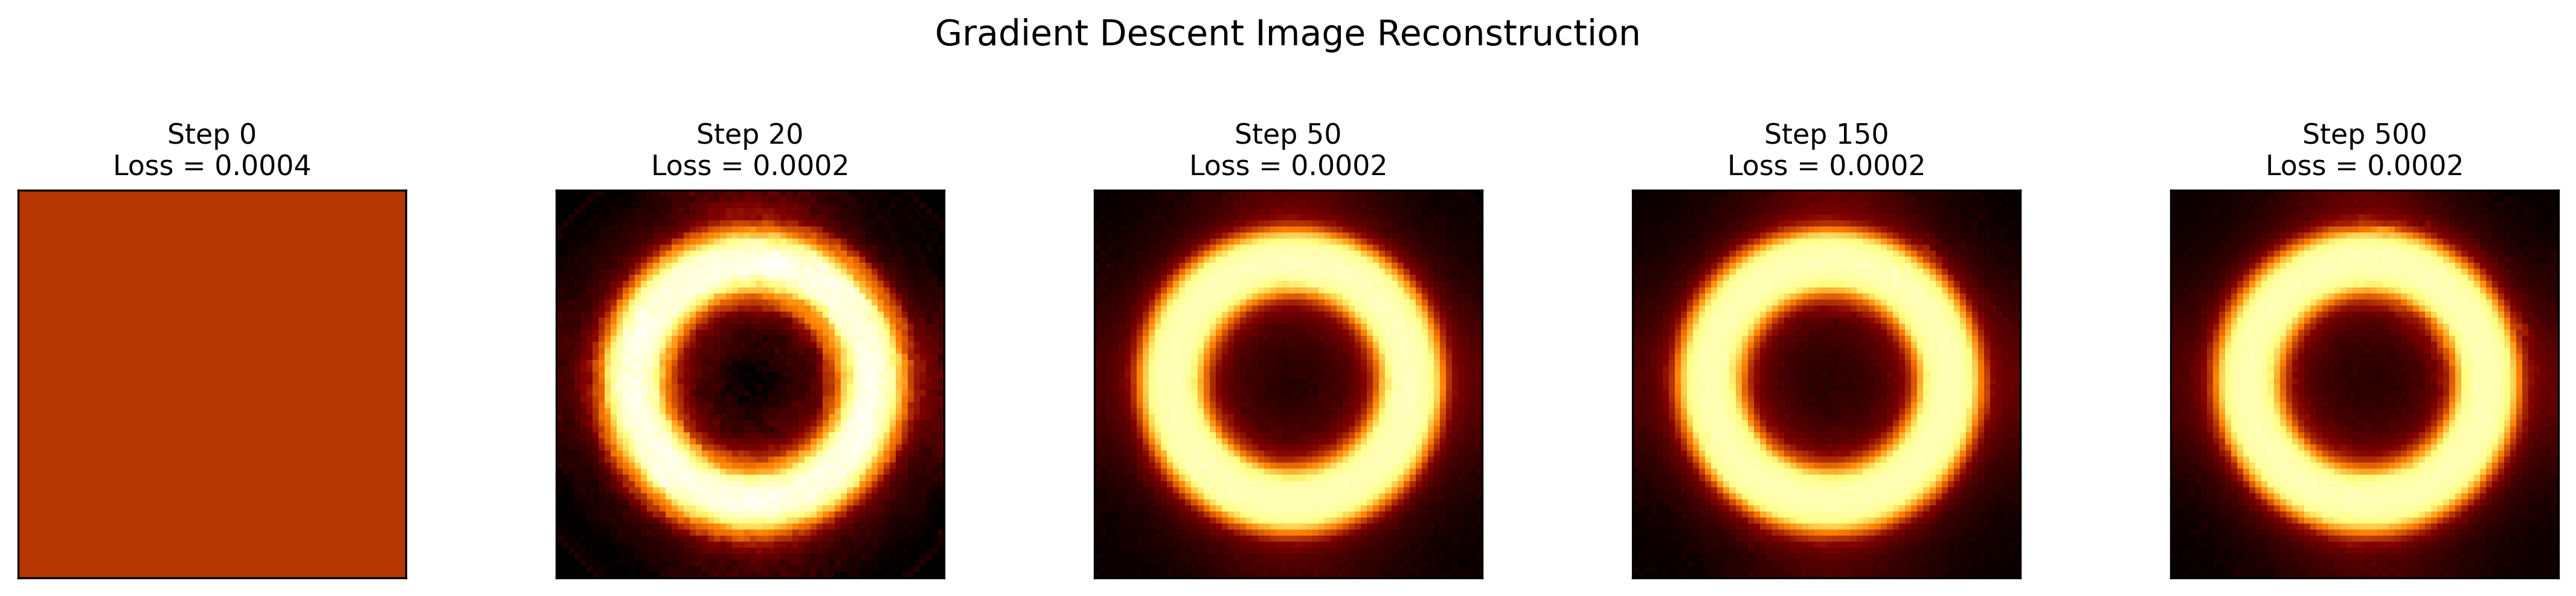

In [53]:
# Progressive visualization: watch the ring emerge!

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

vmax = max(s.max() for s in snapshots.values())

for idx, step in enumerate(snapshot_steps):
    ax = axes[idx]
    ax.imshow(snapshots[step], cmap='afmhot', origin='lower', vmin=0, vmax=vmax)
    loss_at_step = losses[min(step, len(losses)-1)]
    ax.set_title(f'Step {step}\nLoss = {loss_at_step:.4f}', fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Gradient Descent Image Reconstruction',
             fontsize=14, y=1.08)
plt.tight_layout()
plt.show()

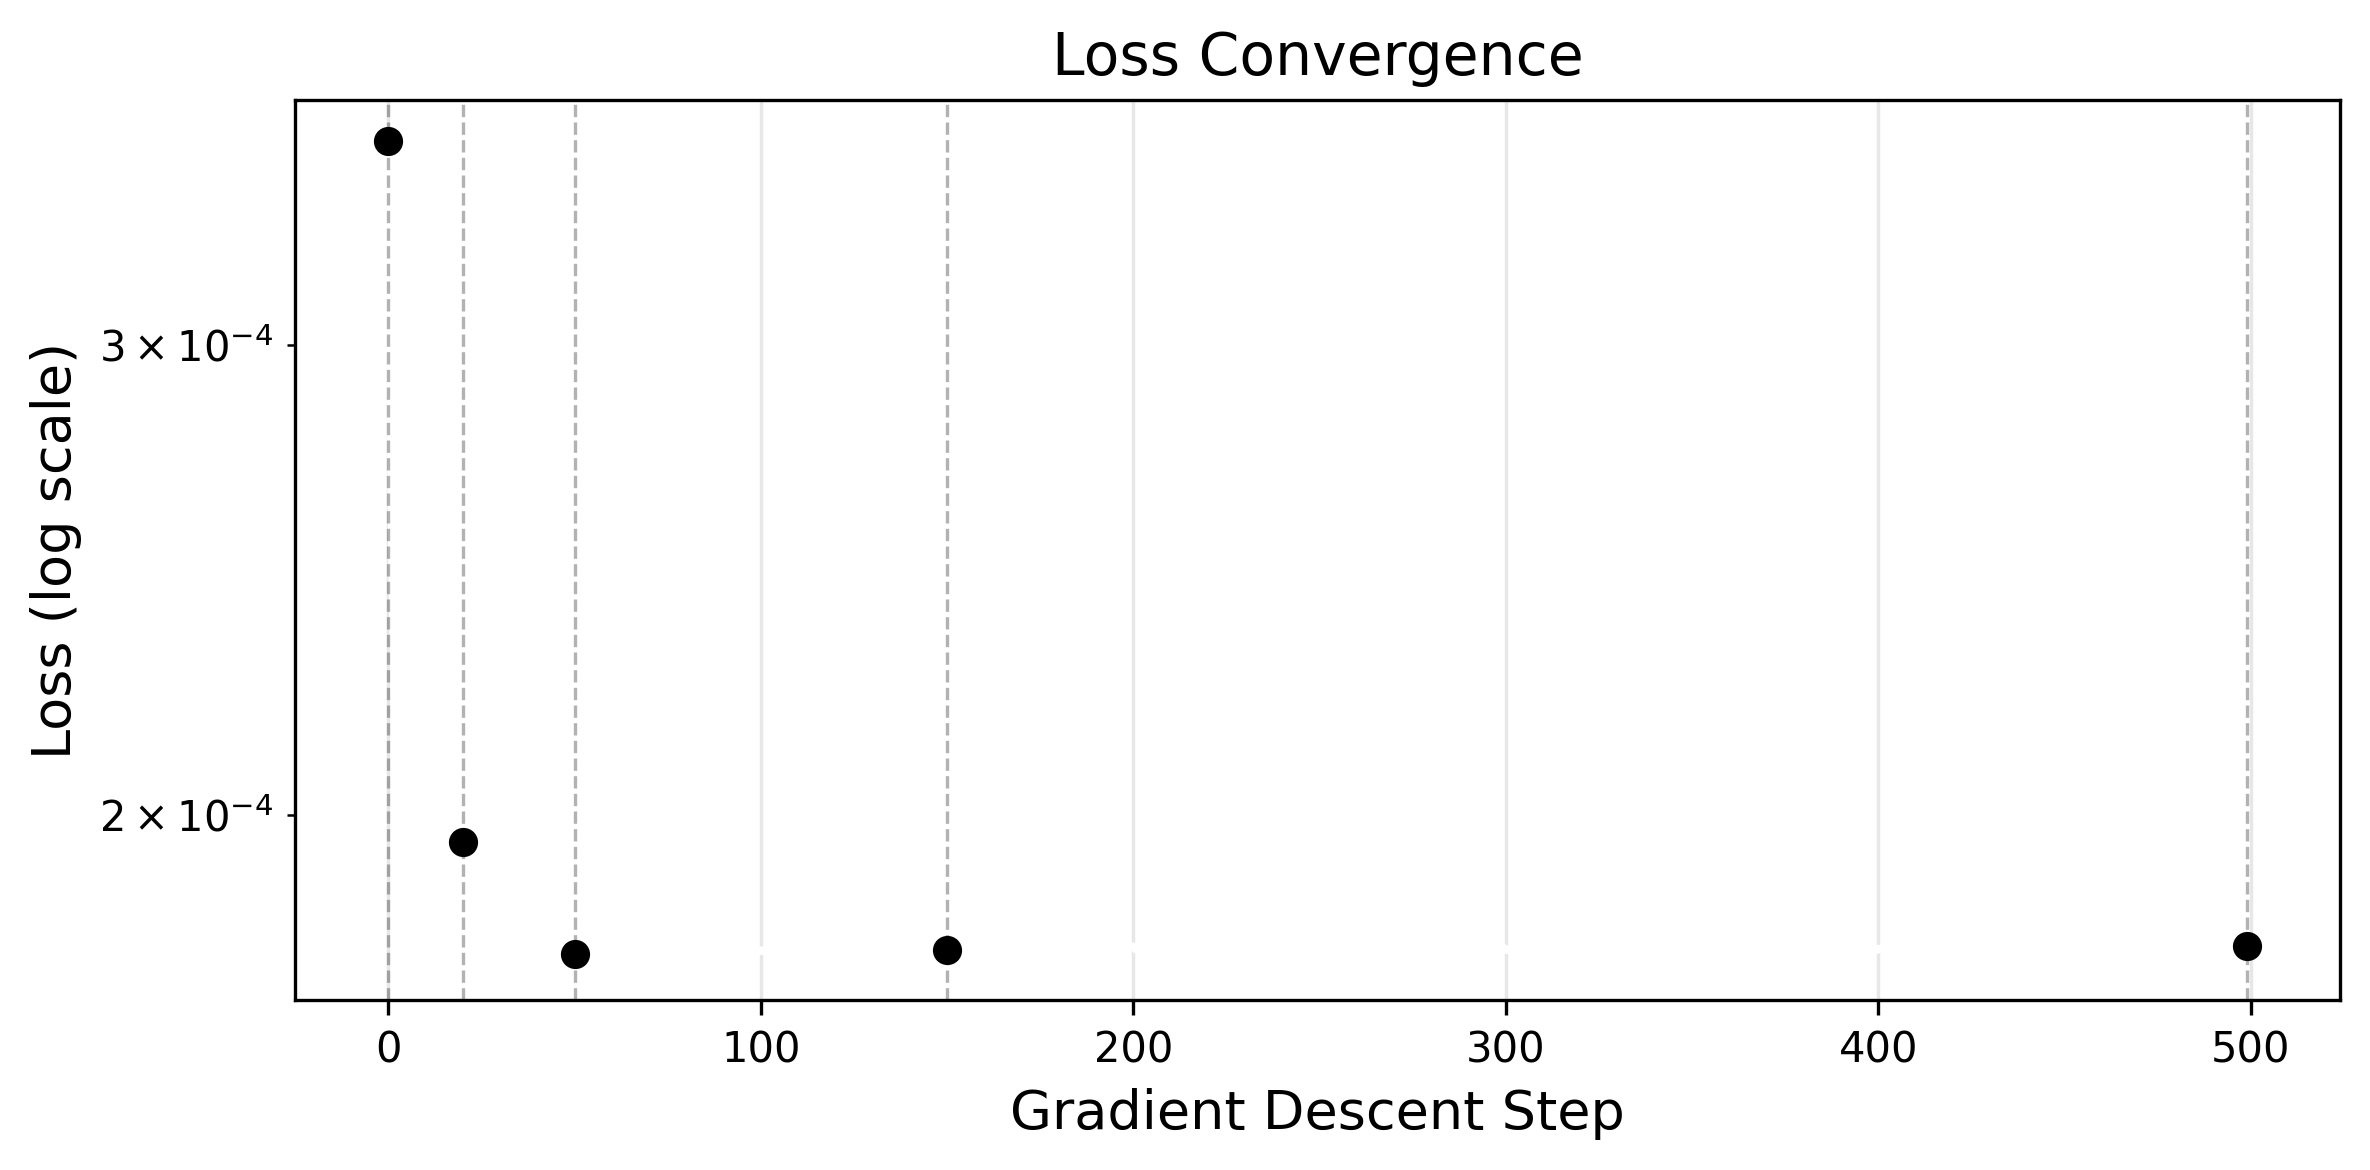

In [54]:
# Loss convergence curve

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.semilogy(losses, color='white', lw=2)
ax.set_xlabel('Gradient Descent Step', fontsize=13)
ax.set_ylabel('Loss (log scale)', fontsize=13)
ax.set_title('Loss Convergence', fontsize=14)
ax.grid(True, alpha=0.3)

# Mark snapshot points
for step in snapshot_steps:
    s = min(step, len(losses)-1)
    ax.axvline(s, color='k', alpha=0.3, ls='--', lw=0.8)
    ax.plot(s, losses[s], 'o', color='k', markersize=6)

plt.tight_layout()
plt.show()

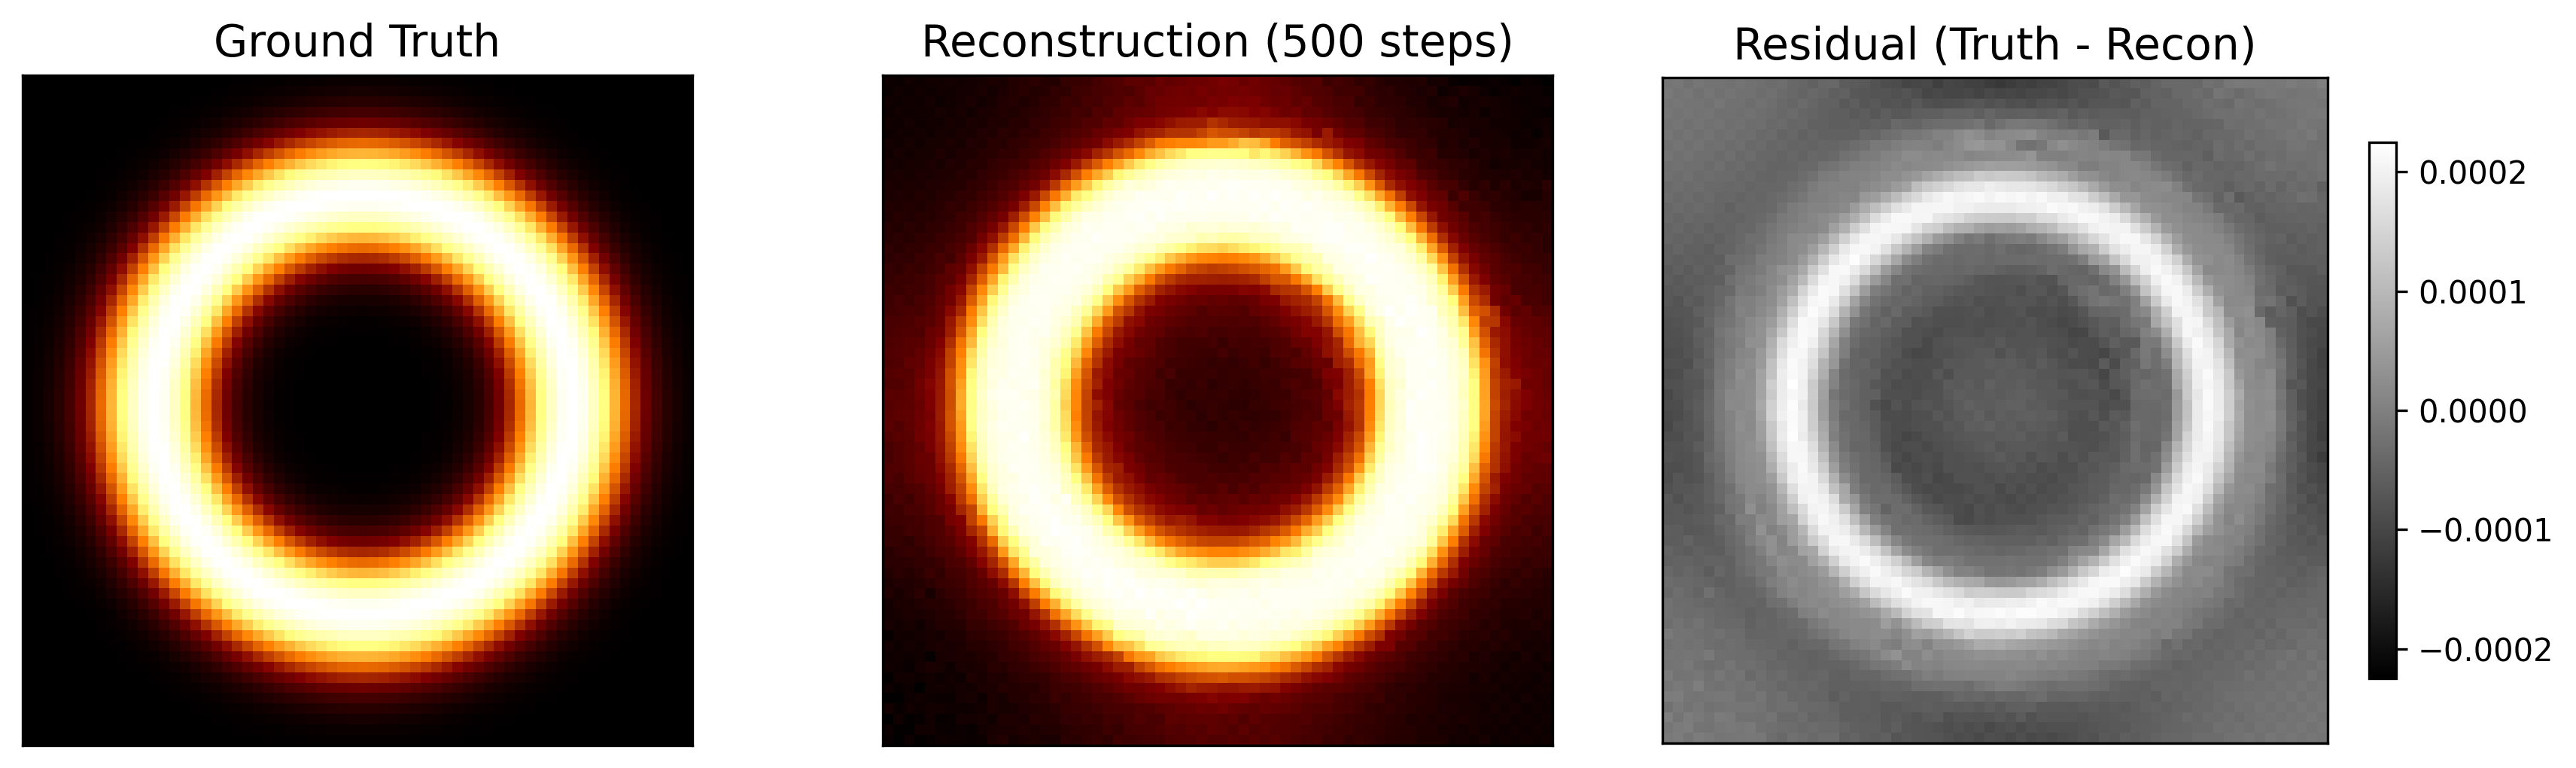

Truth peak: 0.00079, Reconstruction peak: 0.00059
With complete Fourier data, gradient descent recovers the ring beautifully.


In [56]:
# Side-by-side comparison: Ground Truth | Reconstruction | Residual

final_img = np.array(jnp.clip(img, 0, None).reshape(N, N))
truth = ring64

residual = truth - final_img

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# Each panel uses its own scale so the structure is visible
im0 = axes[0].imshow(truth, cmap='afmhot', origin='lower')
axes[0].set_title('Ground Truth', fontsize=14)

im1 = axes[1].imshow(final_img, cmap='afmhot', origin='lower')
axes[1].set_title(f'Reconstruction ({n_steps} steps)', fontsize=14)

res_max = np.max(np.abs(residual))
im2 = axes[2].imshow(residual, cmap='gray', origin='lower', vmin=-res_max, vmax=res_max)
axes[2].set_title('Residual (Truth - Recon)', fontsize=14)
plt.colorbar(im2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

print(f"Truth peak: {truth.max():.5f}, Reconstruction peak: {final_img.max():.5f}")
print(f"With complete Fourier data, gradient descent recovers the ring beautifully.")

### Pause and appreciate what just happened.

The ring structure wasn't put in by hand. It **emerged** because gradient descent found the image whose Fourier transform best matches the observed data, while also being smooth (low TV).

This is the **exact same gradient descent loop** as our polynomial fit in Notebook 1.
- Same `jax.grad`
- Same update rule: $\theta \leftarrow \theta - \eta \nabla \mathcal{L}$
- **Different model, different loss — same recipe.**

---

### What happens with SPARSE Fourier data?

With complete Fourier coverage, reconstruction is straightforward. But the EHT doesn't measure all Fourier components, it measures a tiny fraction.

Let's see what happens when we keep only **10%** of the Fourier components, the same situation we explored with the "dirty image".

Keeping 434 of 4096 Fourier components (10.6%)


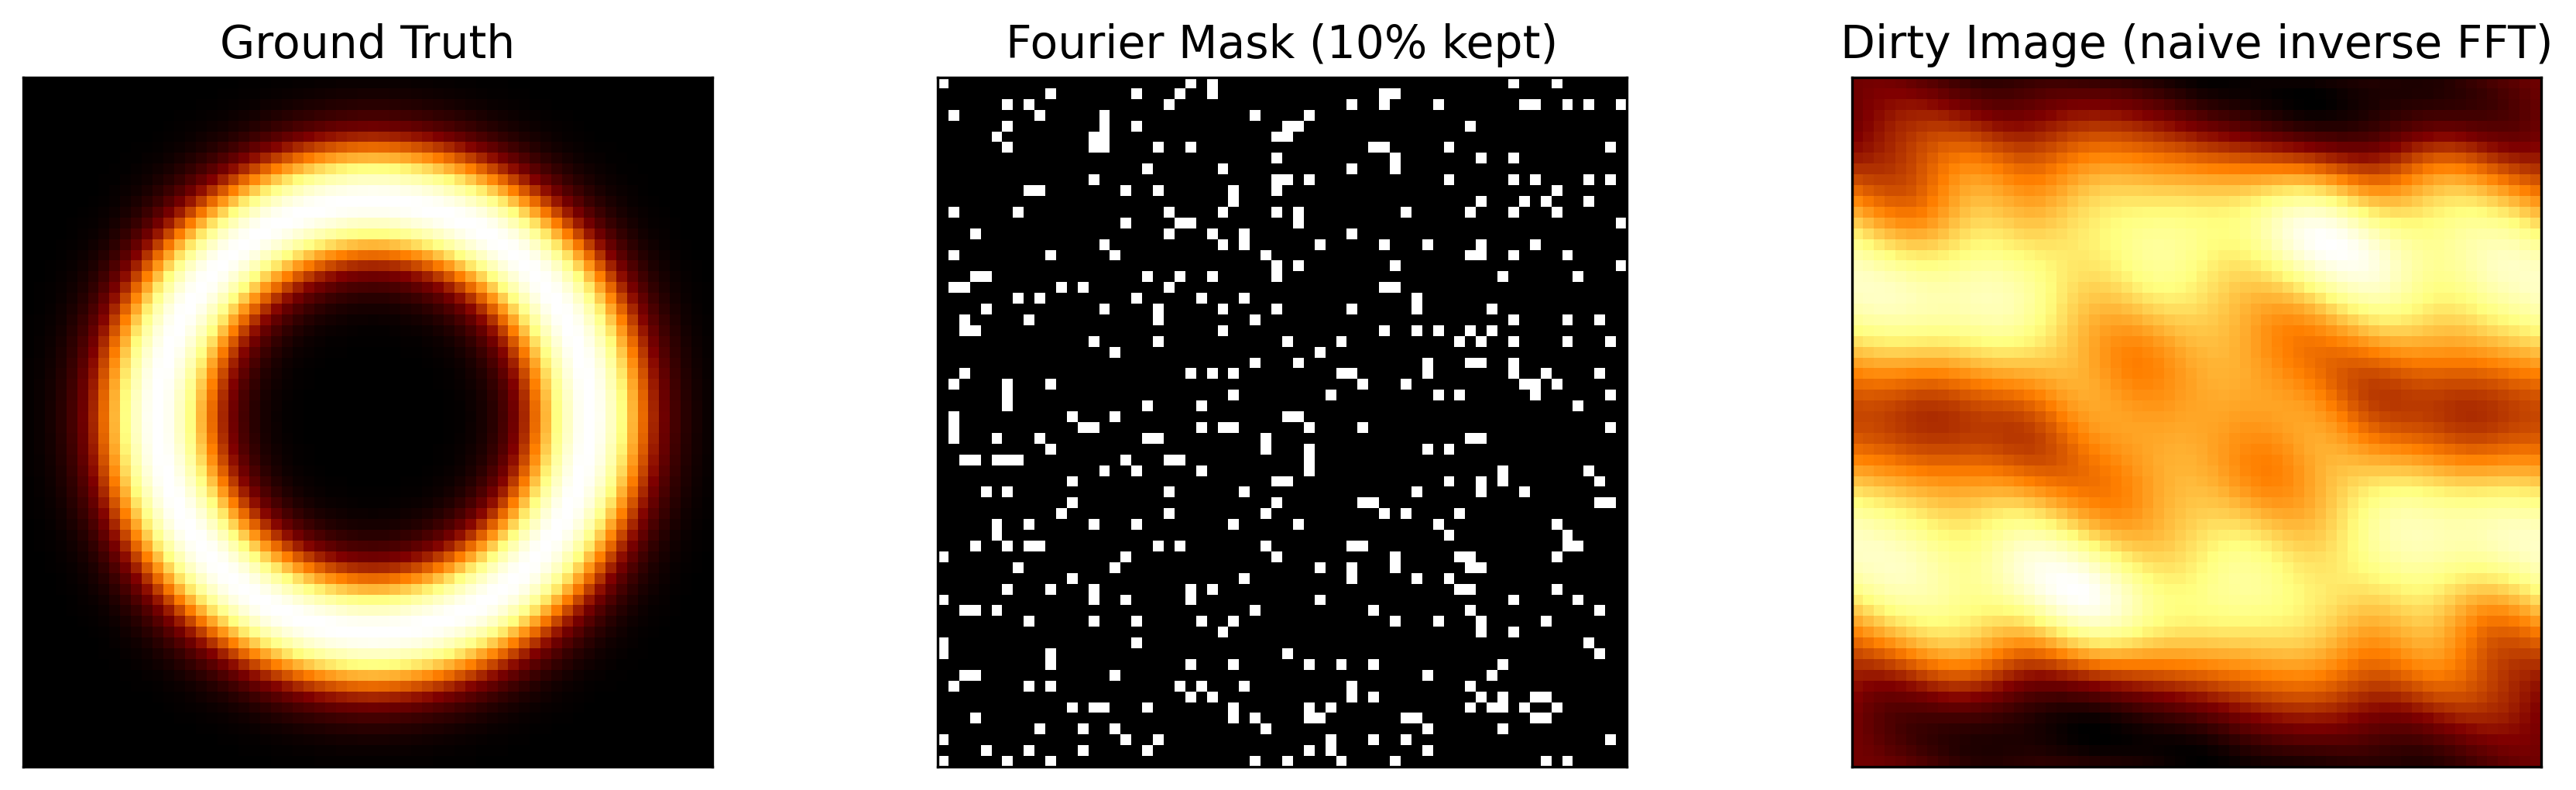


The dirty image is full of artifacts — the ring is barely visible.
With complete data, gradient descent easily recovers the ring.
With sparse data (like the EHT), the problem is underdetermined and much harder.

Professional tools like ehtim (Notebook 3) use sophisticated optimization
and regularization to handle this.


In [58]:
# === SPARSE Fourier data: keep only 10% of components ===

np.random.seed(42)
frac_keep = 0.10
sparse_mask = np.random.random((N, N)) < frac_keep
sparse_mask[0, 0] = True  # Always keep the DC component

# Masked FFT data
full_fft = np.fft.fft2(ring64)
sparse_fft = full_fft * sparse_mask

# Dirty image: naive inverse FFT of the sparse data
dirty_image_sparse = np.fft.ifft2(sparse_fft).real

n_kept = sparse_mask.sum()
print(f"Keeping {n_kept} of {N*N} Fourier components ({100*n_kept/(N*N):.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].imshow(ring64, cmap='afmhot', origin='lower')
axes[0].set_title('Ground Truth', fontsize=14)

axes[1].imshow(sparse_mask, cmap='gray', origin='lower')
axes[1].set_title(f'Fourier Mask ({100*frac_keep:.0f}% kept)', fontsize=14)

axes[2].imshow(dirty_image_sparse, cmap='afmhot', origin='lower')
axes[2].set_title('Dirty Image (naive inverse FFT)', fontsize=14)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

print("\nThe dirty image is full of artifacts — the ring is barely visible.")
print("With complete data, gradient descent easily recovers the ring.")
print("With sparse data (like the EHT), the problem is underdetermined and much harder.")
print("\nProfessional tools like ehtim (Notebook 3) use sophisticated optimization")
print("and regularization to handle this.")

---

## Step 2.4: The Effect of TV Regularization

In Notebook 1, we saw that polynomial degree controls the bias-variance tradeoff. Here, $\lambda_{\text{TV}}$ plays the same role:

- **$\lambda_{\text{TV}} = 0$**: No regularization. The reconstruction is sharp but may have noise artifacts.
- **$\lambda_{\text{TV}}$ moderate**: Slight smoothing. A good balance.
- **$\lambda_{\text{TV}}$ too large**: Over-regularization. The image is too smooth, losing real structure.

Let's see this in action with our full-FFT reconstruction.

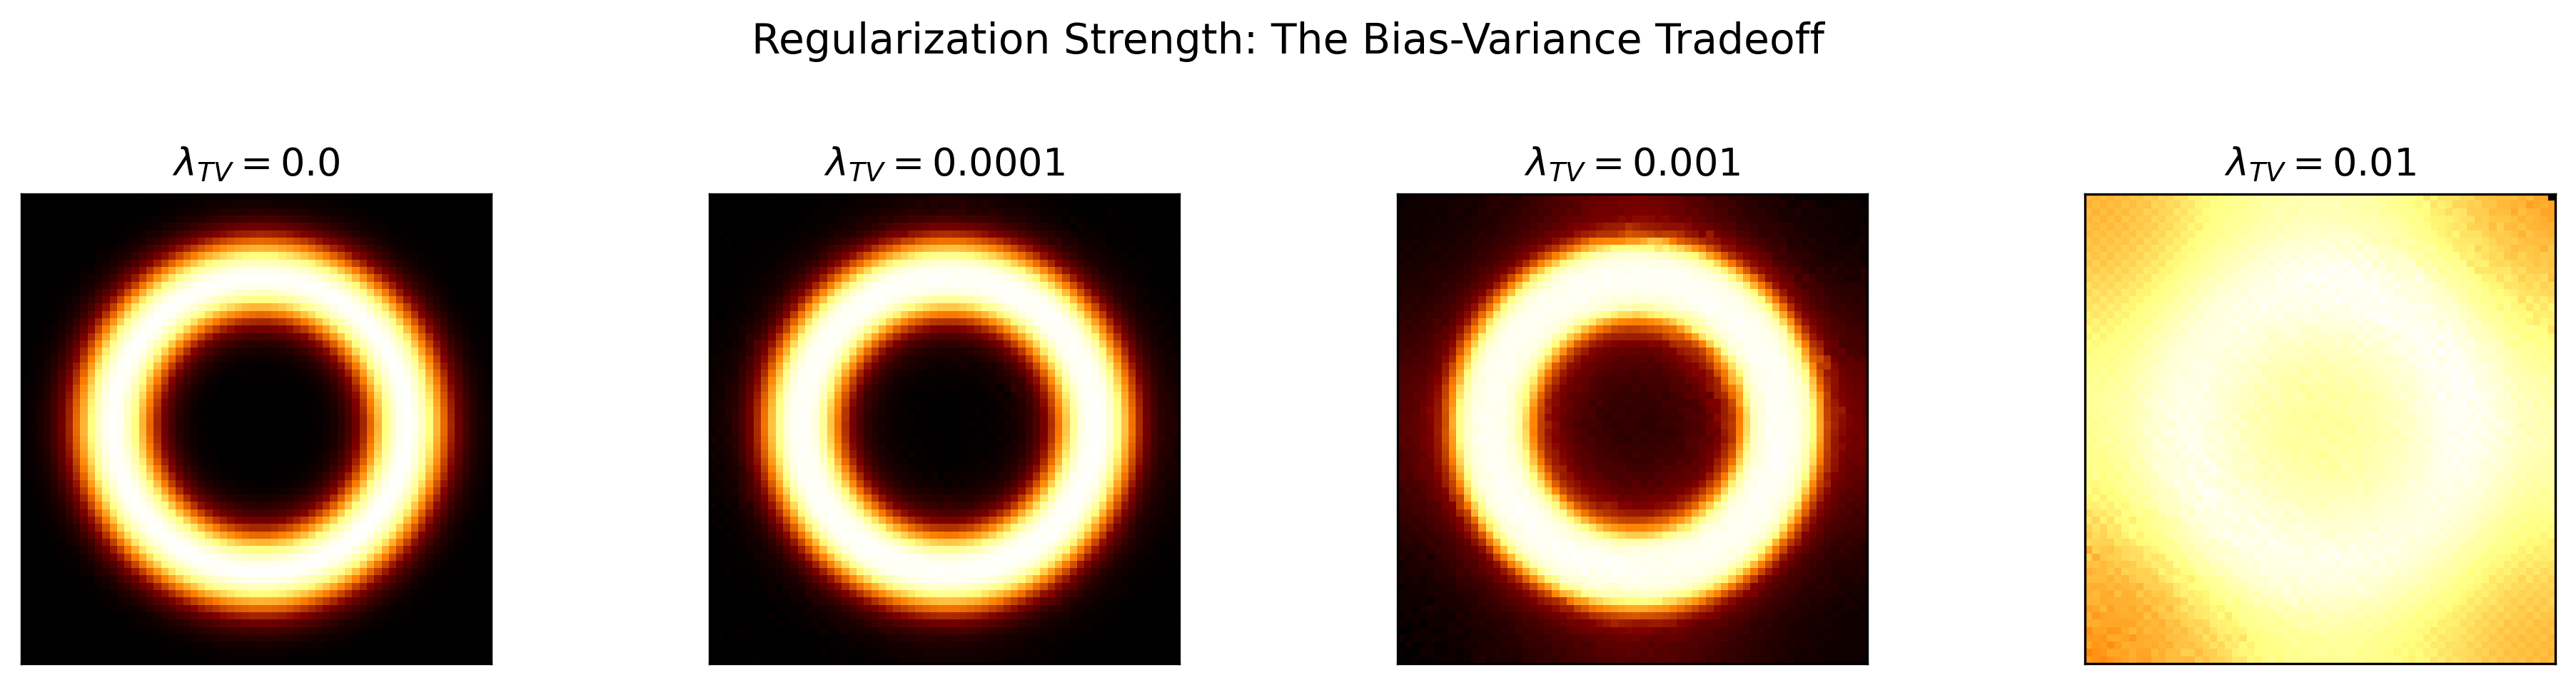

lambda_TV = 0: sharpest, but may have noise artifacts
lambda_TV moderate: smooth and clean
lambda_TV too large: over-smoothed, losing detail

This is the SAME bias-variance tradeoff you saw with polynomial degree in Notebook 1!


In [60]:
# Explore different TV regularization strengths using the FFT reconstruction

def reconstruct_tv(lam_tv=0.001, n_steps=500, lr=0.0001):
    """Reconstruct the ring with a given TV weight."""
    def loss(img_flat):
        image = img_flat.reshape(N, N)
        model_fft = jnp.fft.fft2(image)
        chi2 = jnp.mean(jnp.abs(model_fft - obs_fft)**2)
        return chi2 + lam_tv * total_variation(image)
    
    gf = jax.jit(jax.grad(loss))
    im = jnp.ones(N * N, dtype=jnp.float32) / (N * N)
    m_t = jnp.zeros_like(im)
    v_t = jnp.zeros_like(im)
    for step in range(1, n_steps + 1):
        g = gf(im)
        m_t = 0.9 * m_t + 0.1 * g
        v_t = 0.999 * v_t + 0.001 * g**2
        im = jnp.clip(im - lr * (m_t/(1-0.9**step)) / (jnp.sqrt(v_t/(1-0.999**step)) + 1e-8), 0, None)
    return np.array(im.reshape(N, N))

lam_tv_values = [0.0, 0.0001, 0.001, 0.01]

fig, axes = plt.subplots(1, len(lam_tv_values), figsize=(13, 3))

for idx, ltv in enumerate(lam_tv_values):
    recon = reconstruct_tv(lam_tv=ltv)
    axes[idx].imshow(recon, cmap='afmhot', origin='lower')
    axes[idx].set_title(f'$\\lambda_{{TV}} = {ltv}$', fontsize=13)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

plt.suptitle('Regularization Strength: The Bias-Variance Tradeoff',
             fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("lambda_TV = 0: sharpest, but may have noise artifacts")
print("lambda_TV moderate: smooth and clean")
print("lambda_TV too large: over-smoothed, losing detail")
print("\nThis is the SAME bias-variance tradeoff you saw with polynomial degree in Notebook 1!")

---

## You went from fitting a polynomial to reconstructing a (toy) black hole image.

The ML recipe is always the same:

| Step | What it does |
|---|---|
| **1. Model** | $f_\theta(\text{input}) \to \text{prediction}$ |
| **2. Loss** | $\mathcal{L}(\theta) = \text{how wrong are we?}$ |
| **3. Gradient** | `jax.grad(loss)` $\to \nabla_\theta \mathcal{L}$ |
| **4. Update** | $\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}$ |

### Connection to Bayesian Statistics

If you took the statistics lecture, you learned about Bayes' theorem. Our reconstruction is a **Maximum A Posteriori (MAP)** estimate:

$$\hat{I}_{\text{MAP}} = \arg\max_I \;\underbrace{P(\text{data}|I)}_{\text{Likelihood} \sim e^{-\chi^2/2}} \;\cdot\; \underbrace{P(I)}_{\text{Prior} \sim e^{-\lambda_{\text{TV}} \cdot \text{TV}(I)}}$$

- **Likelihood** = chi-squared (data fidelity)
- **Prior** = regularization (TV, entropy, etc.)
- **MAP estimate** = our reconstruction (minimizing the loss = maximizing the posterior)

---